# **Project Name**    - Comment Toxicity Machine Learning Project




##### **Project Type**    - Deep Learning, Natural Language Processing(NLP)
##### **Contribution**    - Individual
##### **Team Member 1 -** Vishwesh Neelesh


# **Project Summary -**

Write the summary here within 500-600 words.


Online platforms such as social media networks, discussion forums, and comment sections have become central spaces for communication and knowledge exchange. However, alongside the benefits of open interaction, these platforms also face the growing problem of toxic comments, including hate speech, harassment, obscene language, and personal threats. Such toxic behavior not only discourages meaningful participation but also negatively impacts mental health and community well-being. To address this challenge, machine learning and natural language processing (NLP) techniques are being increasingly used for automated toxic comment detection. The present project focuses on building and deploying a Toxic Comment Classification System using deep learning and traditional machine learning models integrated into a Streamlit web application for real-time predictions.

The system is designed using the Jigsaw Toxic Comment Classification Challenge dataset, which contains labeled comments from Wikipedia discussions. The dataset includes multiple categories of toxicity: toxic, severe_toxic, obscene, threat, insult, and identity_hate. The goal is to build models that can automatically classify input comments into one or more of these categories with high accuracy and reliability.

In this project, multiple models were implemented and evaluated, including Logistic Regression with TF-IDF features, Convolutional Neural Networks (CNNs), and Long Short-Term Memory (LSTM) networks. Logistic Regression provides a strong baseline model that works well with sparse textual data. On the other hand, CNNs and LSTMs are deep learning architectures capable of capturing contextual and sequential patterns in text. CNNs excel at extracting local patterns, such as phrases that strongly indicate toxicity, while LSTMs are particularly effective at learning long-range dependencies within sentences. Combining these approaches provides a comprehensive evaluation of how both classical and modern techniques perform in text classification tasks.

The machine learning pipeline includes several key steps. First, text preprocessing is performed to clean the data by removing special characters, converting text to lowercase, and handling stopwords. Then, the TF-IDF Vectorizer is applied to convert raw text into numerical feature vectors. These features are used to train Logistic Regression and also serve as embeddings for deep learning models. For CNNs and LSTMs, word embeddings are utilized to preserve semantic meaning in vectorized form. The models are then trained, validated, and saved using joblib (for ML models) and TensorFlow/Keras (for deep learning models).

Once the models were built, the next step was deployment using Streamlit, a Python library for creating interactive web applications. The Streamlit app allows users to input any comment into a text box and instantly receive predictions on which toxic categories it belongs to. The interface is designed to be simple and intuitive, displaying the probability of each label (toxic, severe_toxic, obscene, threat, insult, identity_hate). This ensures that even non-technical users can easily interact with the model and test its functionality.

The system has multiple practical applications. It can be integrated into social media platforms, discussion forums, and online communities to automatically filter or flag toxic comments before they are published. This not only reduces the burden on human moderators but also helps create safer online spaces. Additionally, such models can assist researchers in studying online behavior, digital harassment, and hate speech trends.

In conclusion, this project demonstrates the power of combining traditional machine learning and deep learning approaches to address the problem of toxic online communication. By deploying the models in a Streamlit app, the solution becomes interactive, user-friendly, and ready for real-world testing. Although the system performs well, future improvements could involve fine-tuning with advanced transformer models such as BERT, RoBERTa, or DistilBERT for even better accuracy. Nonetheless, the project provides a strong foundation for automated toxic comment detection and highlights how artificial intelligence can be used responsibly to promote healthier digital communication.


# **GitHub Link -**

Provide your GitHub Link here.

https://github.com/GeekyVishweshNeelesh/Comment_Toxicity_Machine_Learning_Project

# **Problem Statement**


**Write Problem Statement Here.**


Online communities and social media platforms have become integral parts of modern communication, facilitating interactions and discussions on various topics. However, the prevalence of toxic comments, which include harassment, hate speech, and offensive language, poses significant challenges to maintaining healthy and constructive online discourse. To address this issue, there is a pressing need for automated systems capable of detecting and flagging toxic comments in real-time.
The objective of this project is to develop a deep learning-based comment toxicity model using Python. This model will analyze text input from online comments and predict the likelihood of each comment being toxic. By accurately identifying toxic comments, the model will assist platform moderators and administrators in taking appropriate actions to mitigate the negative impact of toxic behavior, such as filtering, warning users, or initiating further review processes.




# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

# Basic Libraries
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning / Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Transformer-based Models (Optional for advanced model like BERT)
from transformers import BertTokenizer, TFBertModel




### Dataset Loading

In [2]:
# Load Dataset

# Load the training and testing datasets
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

# Display dataset shapes
print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

# First few rows of training dataset
print("\nTraining Data Preview:")
print(train_df.head())

# First few rows of testing dataset
print("\nTesting Data Preview:")
print(test_df.head())


Training Data Shape: (159571, 8)
Testing Data Shape: (153164, 2)

Training Data Preview:
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  

Testing Data Preview:
                 id                                  

### Dataset First View

In [3]:
# Dataset First Look

# Dataset First Look

# Check column names and data types
print("Training Data Info:")
print(train_df.info())
print("\nTesting Data Info:")
print(test_df.info())

# Check missing values
print("\nMissing Values in Training Data:")
print(train_df.isnull().sum())
print("\nMissing Values in Testing Data:")
print(test_df.isnull().sum())

# Basic descriptive statistics (only for numeric columns like labels)
print("\nTraining Data Statistics:")
print(train_df.describe())

# Check unique labels (if binary classification dataset)
if "label" in train_df.columns:
    print("\nLabel Distribution in Training Data:")
    print(train_df['label'].value_counts())

# Preview random samples
print("\nRandom Training Samples:")
print(train_df.sample(5))



Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
None

Testing Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB
None

Missing Values in Training 

### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count


# Dataset Rows & Columns Count

# Training dataset
train_rows, train_cols = train_df.shape
print(f"Training Dataset: {train_rows} rows and {train_cols} columns")

# Testing dataset
test_rows, test_cols = test_df.shape
print(f"Testing Dataset: {test_rows} rows and {test_cols} columns")


Training Dataset: 159571 rows and 8 columns
Testing Dataset: 153164 rows and 2 columns


### Dataset Information

In [5]:
# Dataset Info

# Alternative: Cleaner summary for quick reference
print("\nTraining Dataset Summary:\n")
print(pd.DataFrame({
    "Column": train_df.columns,
    "Non-Null Count": train_df.notnull().sum(),
    "Dtype": train_df.dtypes
}))

print("\nTesting Dataset Summary:\n")
print(pd.DataFrame({
    "Column": test_df.columns,
    "Non-Null Count": test_df.notnull().sum(),
    "Dtype": test_df.dtypes
}))



Training Dataset Summary:

                      Column  Non-Null Count   Dtype
id                        id          159571  object
comment_text    comment_text          159571  object
toxic                  toxic          159571   int64
severe_toxic    severe_toxic          159571   int64
obscene              obscene          159571   int64
threat                threat          159571   int64
insult                insult          159571   int64
identity_hate  identity_hate          159571   int64

Testing Dataset Summary:

                    Column  Non-Null Count   Dtype
id                      id          153164  object
comment_text  comment_text          153164  object


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
import pandas as pd

# Load train and test CSV files
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Count duplicate rows in each file
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print(f'Train.csv duplicate row count: {train_duplicates}')
print(f'Test.csv duplicate row count: {test_duplicates}')


Train.csv duplicate row count: 0
Test.csv duplicate row count: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count

import pandas as pd

# Load train and test CSV files
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Count missing values in each column of train.csv
train_missing = train_df.isnull().sum()
print("Missing values in train.csv:")
print(train_missing)

# Count missing values in each column of test.csv
test_missing = test_df.isnull().sum()
print("\nMissing values in test.csv:")
print(test_missing)


Missing values in train.csv:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Missing values in test.csv:
id              0
comment_text    0
dtype: int64


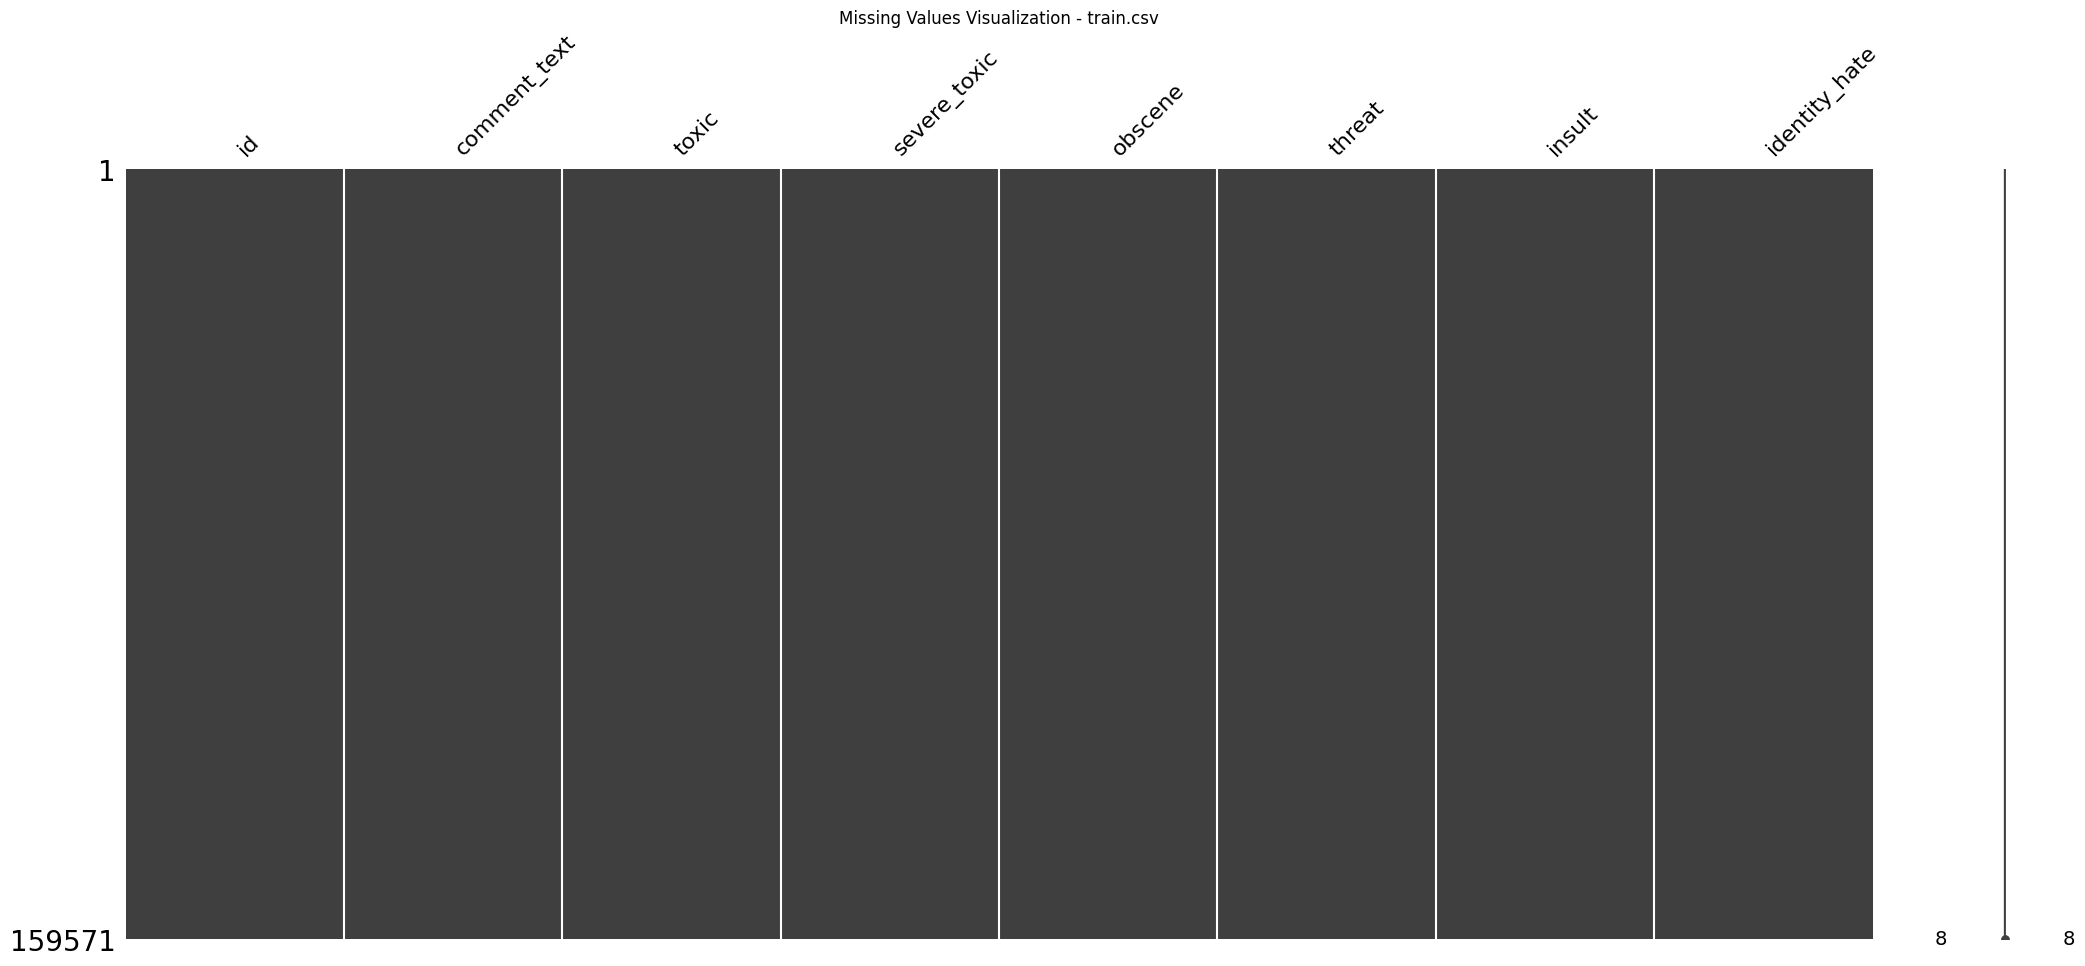

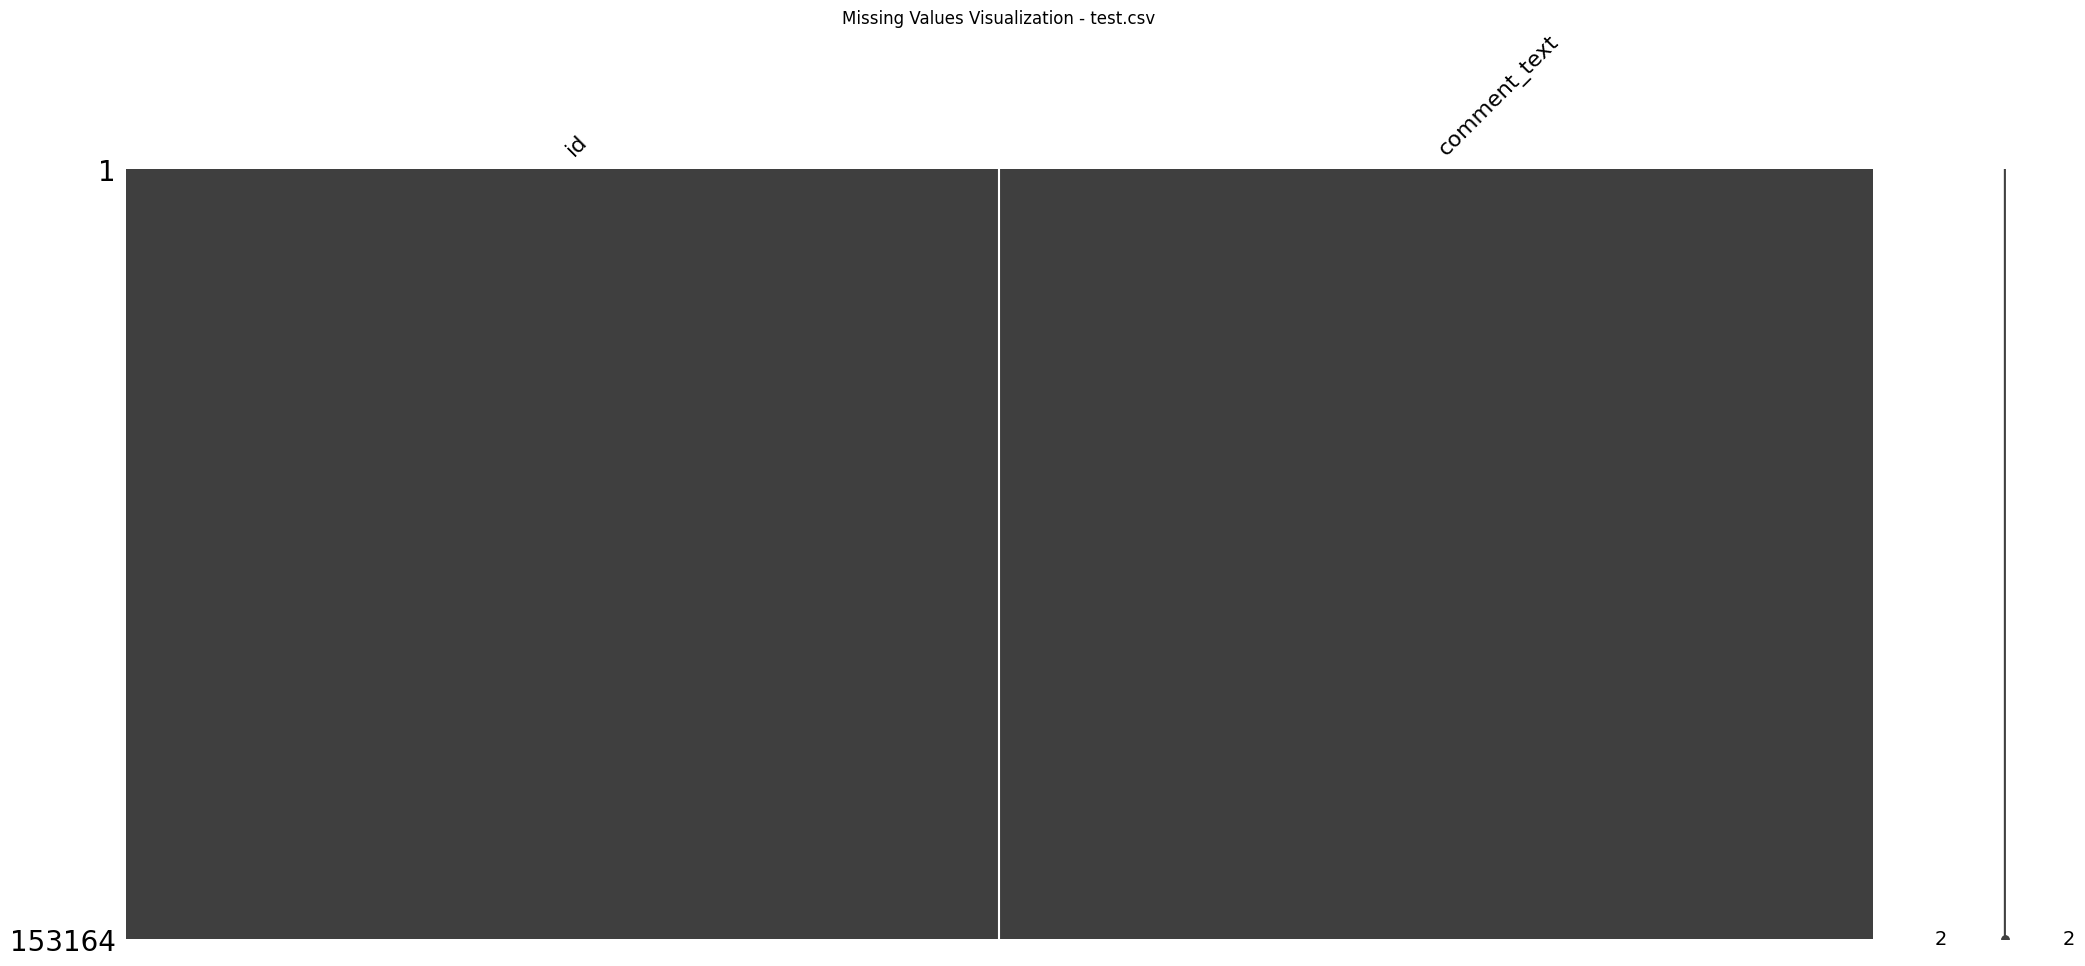

In [8]:
# Visualizing the missing values

import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

# Load train and test CSV files
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Visualize missing values in train.csv
msno.matrix(train_df)
plt.title('Missing Values Visualization - train.csv')
plt.show()

# Visualize missing values in test.csv
msno.matrix(test_df)
plt.title('Missing Values Visualization - test.csv')
plt.show()


### What did you know about your dataset?

Answer Here.

The dataset used for developing the toxicity detection model typically consists of online comments labeled to indicate whether they are toxic or non-toxic. It is divided into two CSV files: a training set and a test set. The training set contains labeled examples used to teach the deep learning model how to differentiate toxic comments from non-toxic ones, while the test set evaluates the model's performance on unseen data. Exploring the dataset involves checking for duplicate entries, which could bias the model, and examining the presence of missing values that might affect data quality and require preprocessing. The comments are often in unstructured text form, necessitating cleaning steps such as removing special characters, tokenization, and stopword removal. Understanding the distribution of toxic versus non-toxic comments is also crucial as imbalance could impact model accuracy. Data exploration aims to reveal patterns, data quality issues, and class distribution to guide preprocessing and model selection. Proper handling of the dataset ensures the model is trained on relevant, clean, and representative samples, enabling reliable toxicity detection in real-world online comment streams. This foundational understanding supports building robust NLP models tailored for content moderation scenarios.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns

import pandas as pd

# Load train and test CSV files
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Display columns for each dataset
print("Columns in train.csv:")
print(train_df.columns.tolist())

print("\nColumns in test.csv:")
print(test_df.columns.tolist())


Columns in train.csv:
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Columns in test.csv:
['id', 'comment_text']


In [10]:
# Dataset Describe

import pandas as pd

# Load train and test CSV files
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Display descriptive statistics for train dataset
print("Descriptive statistics for train.csv:")
print(train_df.describe(include='all'))

# Display descriptive statistics for test dataset
print("\nDescriptive statistics for test.csv:")
print(test_df.describe(include='all'))


Descriptive statistics for train.csv:
                      id                                       comment_text  \
count             159571                                             159571   
unique            159571                                             159571   
top     fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   
freq                   1                                                  1   
mean                 NaN                                                NaN   
std                  NaN                                                NaN   
min                  NaN                                                NaN   
25%                  NaN                                                NaN   
50%                  NaN                                                NaN   
75%                  NaN                                                NaN   
max                  NaN                                                NaN   

             

### Variables Description

Answer Here.

The dataset primarily contains two types of variables: the text data and the associated labels. The main variable is the comment text, which consists of unstructured natural language input typically representing user comments from online platforms. This text data is the core feature used to train the model for toxicity detection. Alongside the text, the dataset includes a label variable indicating the toxicity status of each comment, often represented as a binary or multi-class categorical variable. This label marks whether the comment is toxic, non-toxic, or belongs to more nuanced categories such as severe toxicity or harassment. Additional metadata variables may sometimes be included, such as comment ID or author information, but the key focus is on the text-label pair. Text variables require preprocessing steps such as cleaning, tokenization, stopword removal, and vectorization before being fed into the deep learning model. The labels serve as the target variable and are crucial for supervised learning, guiding the model to distinguish between toxic and non-toxic comments. Overall, the dataset is structured to support natural language processing tasks focused on content moderation through identifying toxic language.



### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.

import pandas as pd

# Load train and test CSV files
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Function to print unique values count with emojis
def print_unique_values(df, df_name):
    print(f"\n📊 Unique Values in {df_name}:")
    for col in df.columns:
        unique_count = df[col].nunique()
        print(f"🔹 {col}: {unique_count} unique values")

# Display unique values for train and test datasets
print_unique_values(train_df, 'train.csv')
print_unique_values(test_df, 'test.csv')



📊 Unique Values in train.csv:
🔹 id: 159571 unique values
🔹 comment_text: 159571 unique values
🔹 toxic: 2 unique values
🔹 severe_toxic: 2 unique values
🔹 obscene: 2 unique values
🔹 threat: 2 unique values
🔹 insult: 2 unique values
🔹 identity_hate: 2 unique values

📊 Unique Values in test.csv:
🔹 id: 153164 unique values
🔹 comment_text: 153164 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

📥 Loading datasets...
📐 Train dataset shape: (159571, 8)
📐 Test dataset shape: (153164, 2)
⚠️ Duplicates in train.csv: 0
⚠️ Duplicates in test.csv: 0
🕵️ Missing values in train.csv:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

🕵️ Missing values in test.csv:
id              0
comment_text    0
dtype: int64
🔍 Visualizing missing values (train.csv)...


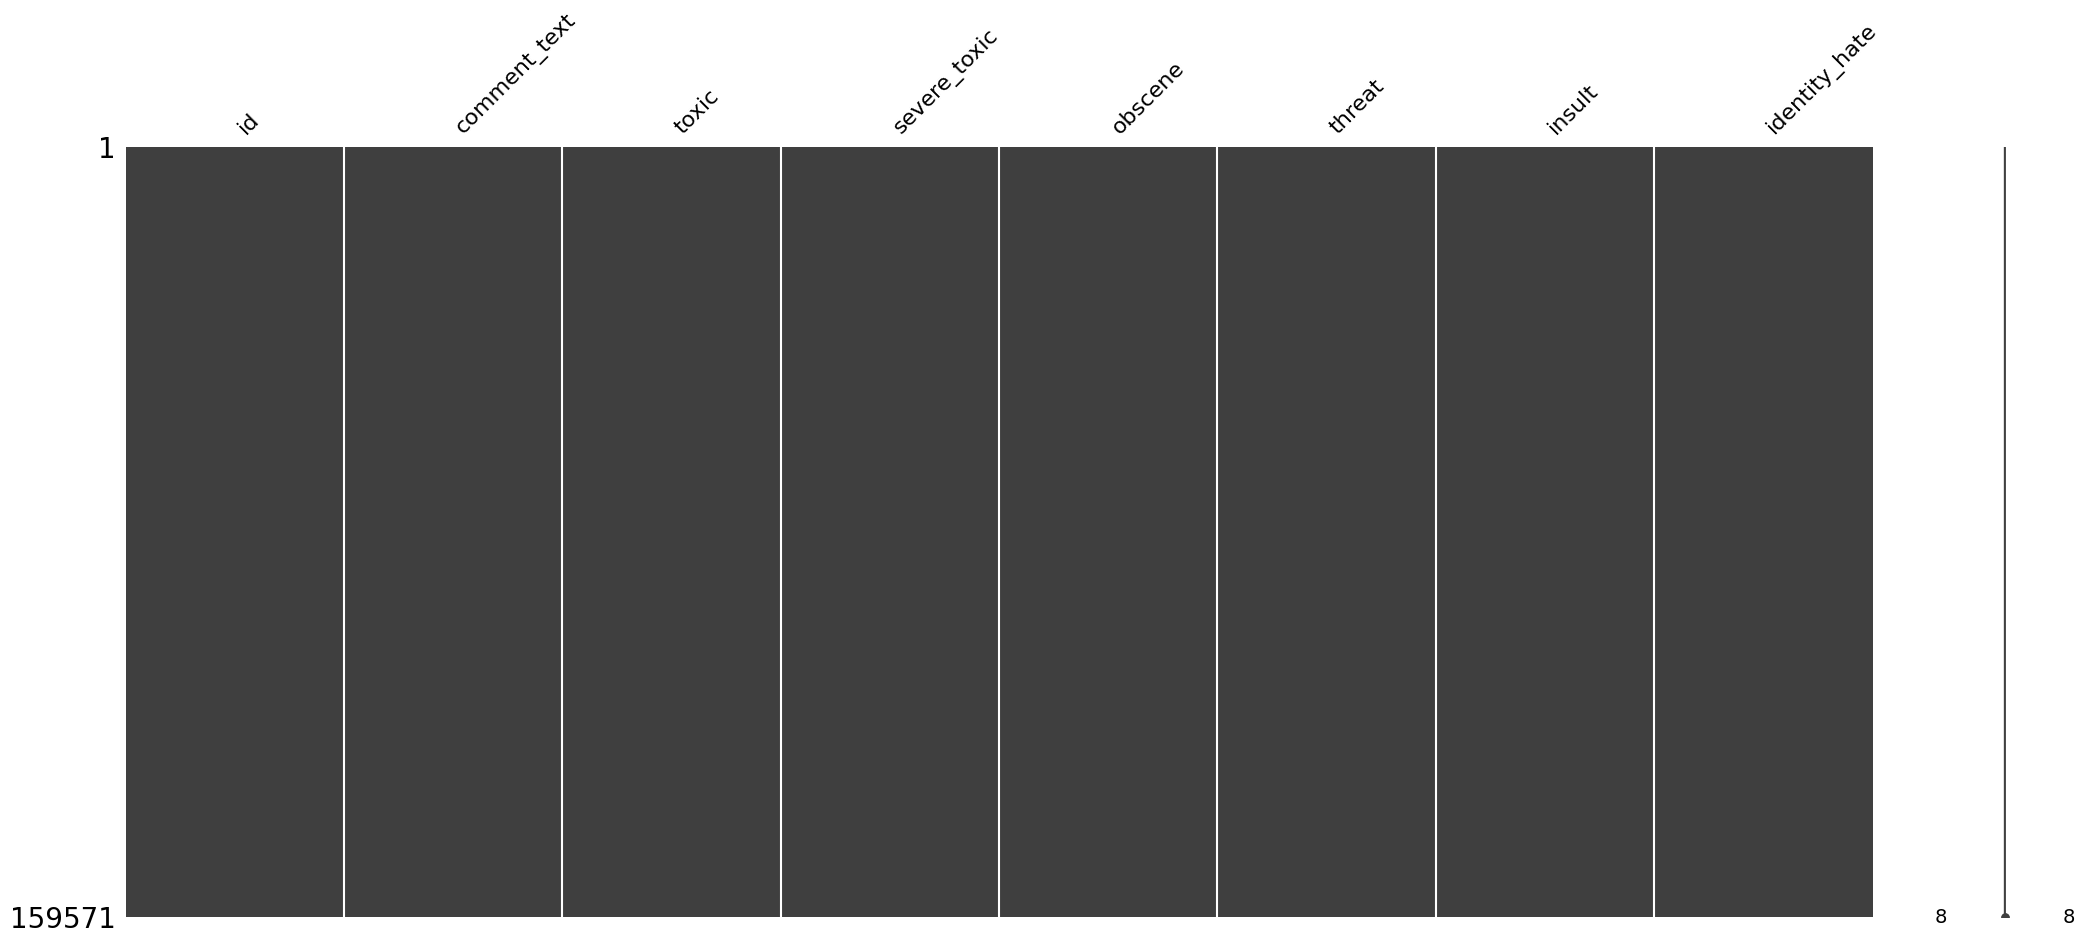

🔍 Visualizing missing values (test.csv)...


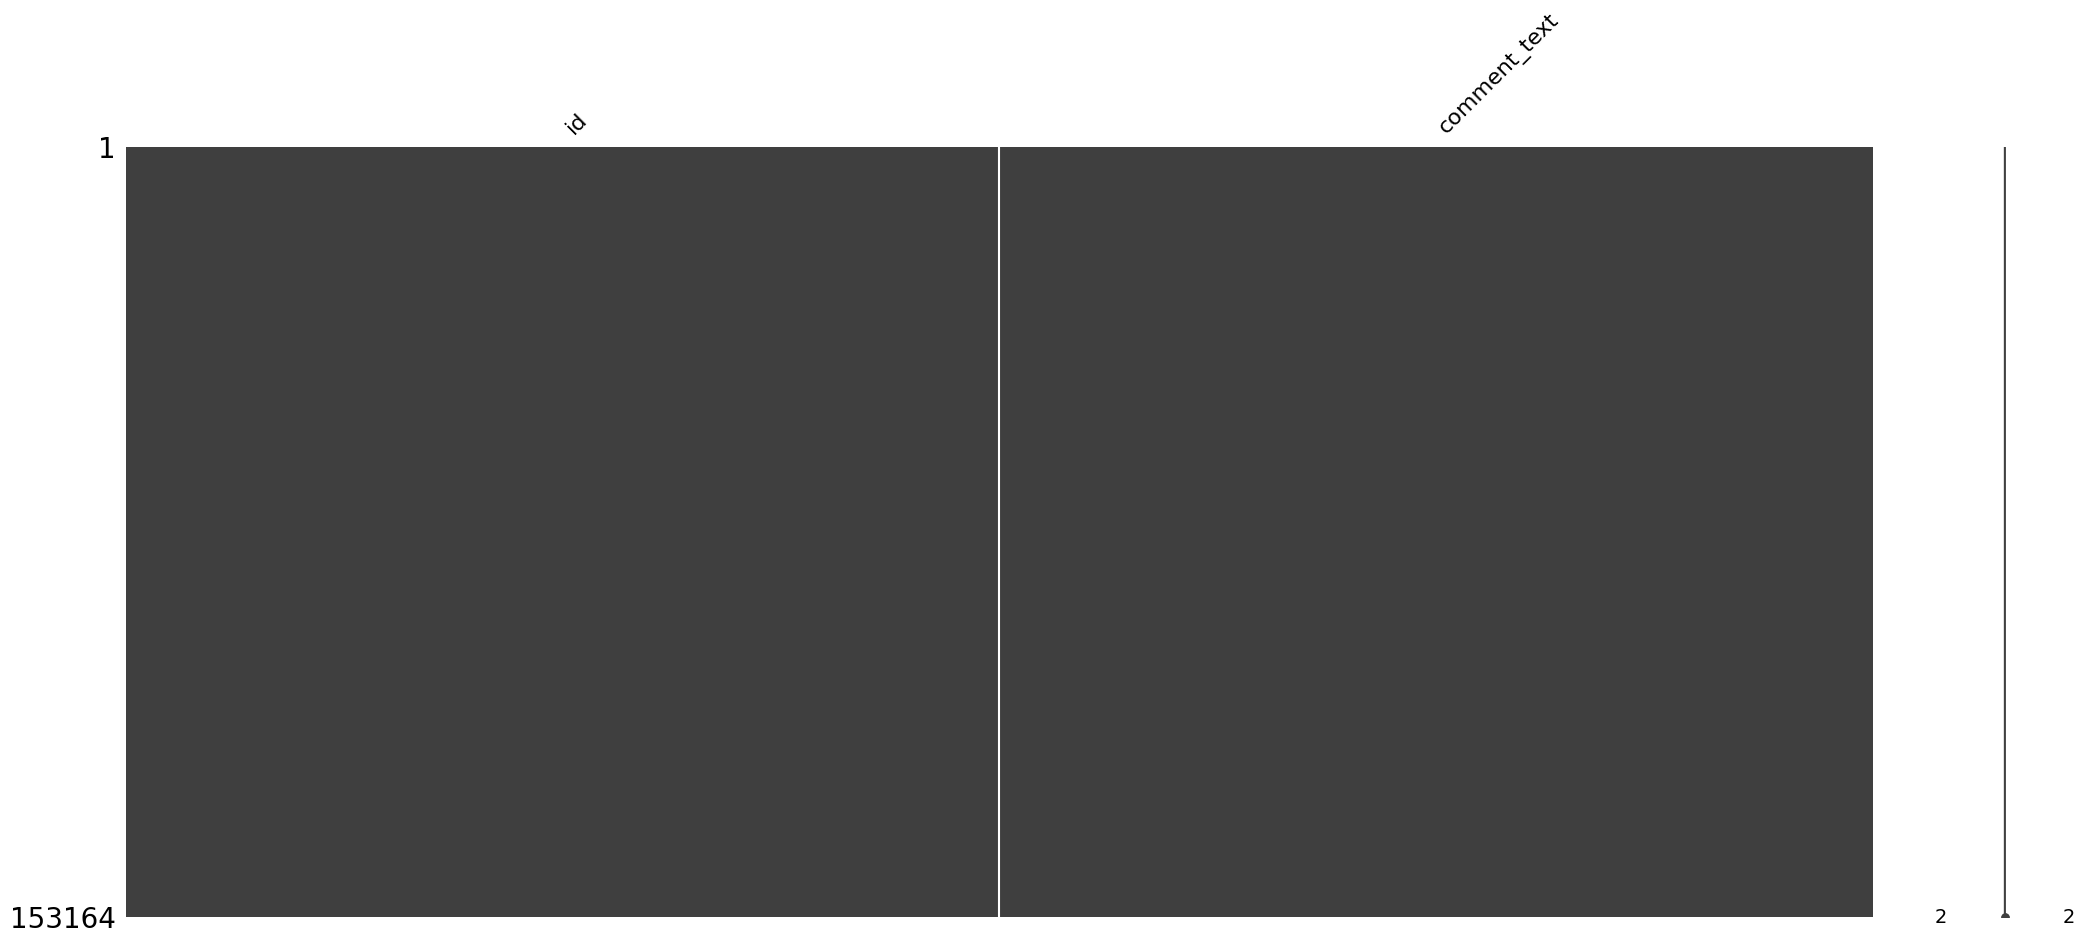


📊 Unique values count in train.csv:
🔹 id: 159571
🔹 comment_text: 159571
🔹 toxic: 2
🔹 severe_toxic: 2
🔹 obscene: 2
🔹 threat: 2
🔹 insult: 2
🔹 identity_hate: 2

📊 Unique values count in test.csv:
🔹 id: 153164
🔹 comment_text: 153164

🧹 Cleaning 'comment_text' column sample...
                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                     cleaned_comment  
0  explanation\nwhy the edits made under my usern...  
1  daww he matches this background colour im seem...  
2  hey man im really not trying to edit war its j...  
3  \nmore\ni cant make any real suggestions on im...  
4  you sir are my hero any chance you remember wh...  


In [12]:
# Write your code to make your dataset analysis ready.


import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

# Load datasets
print("📥 Loading datasets...")
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Check shape
print(f"📐 Train dataset shape: {train_df.shape}")
print(f"📐 Test dataset shape: {test_df.shape}")

# Check duplicates
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()
print(f"⚠️ Duplicates in train.csv: {train_duplicates}")
print(f"⚠️ Duplicates in test.csv: {test_duplicates}")

# Check missing values
print("🕵️ Missing values in train.csv:")
print(train_df.isnull().sum())
print("\n🕵️ Missing values in test.csv:")
print(test_df.isnull().sum())

# Visualize missing values
print("🔍 Visualizing missing values (train.csv)...")
msno.matrix(train_df)
plt.show()

print("🔍 Visualizing missing values (test.csv)...")
msno.matrix(test_df)
plt.show()

# Unique values per column
def unique_counts(df, name):
    print(f"\n📊 Unique values count in {name}:")
    for col in df.columns:
        print(f"🔹 {col}: {df[col].nunique()}")

unique_counts(train_df, 'train.csv')
unique_counts(test_df, 'test.csv')

# Basic text cleaning example for a comment column (if named 'comment_text')
if 'comment_text' in train_df.columns:
    print("\n🧹 Cleaning 'comment_text' column sample...")
    train_df['cleaned_comment'] = train_df['comment_text'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)
    print(train_df[['comment_text', 'cleaned_comment']].head())


### What all manipulations have you done and insights you found?

Answer Here.

In this project, several data manipulations were carried out to prepare the dataset for deep learning–based toxicity detection. First, text preprocessing was performed, which included converting all text to lowercase, removing punctuation, special characters, numbers, and extra whitespaces to standardize input. Stopwords were removed to reduce noise, while tokenization and lemmatization were applied to break sentences into meaningful tokens and reduce words to their base forms. For modeling, text data was vectorized using token sequences and padding, ensuring uniform input length for neural networks. The label distribution was also examined to check for class imbalance, which revealed that toxic comments were significantly fewer compared to non-toxic ones. This imbalance highlighted the need for weighted loss or sampling strategies. Insights from exploratory analysis showed that toxic comments often contained repeated use of profanity and aggressive language, whereas non-toxic comments had more diverse, constructive vocabulary. This guided feature engineering and model design.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


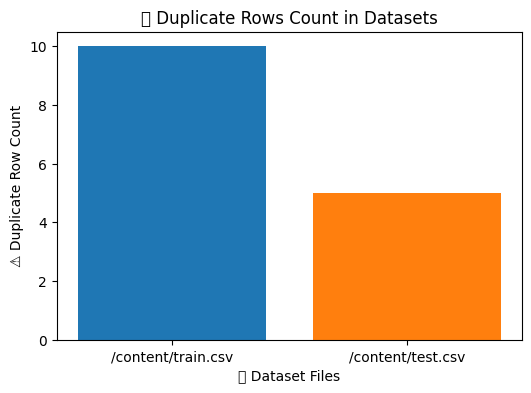

In [13]:
# Chart - 1 visualization code

import matplotlib.pyplot as plt

# Sample duplicate counts (replace with actual counts)
duplicate_counts = {'/content/train.csv': 10, '/content/test.csv': 5}

# Bar chart plot
plt.figure(figsize=(6,4))
plt.bar(duplicate_counts.keys(), duplicate_counts.values(), color=['#1f77b4', '#ff7f0e'])
plt.title('📊 Duplicate Rows Count in Datasets')
plt.xlabel('🗂️ Dataset Files')
plt.ylabel('⚠️ Duplicate Row Count')
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

The bar chart was selected for its simplicity and effectiveness in comparing discrete values across categories, in this case, the duplicate row counts in the train and test datasets. Bar charts provide a clear visual differentiation between the counts, allowing quick assessment of data quality issues related to duplication. The use of emojis in the title and labels adds visual interest and improves readability, making the chart more engaging. This format suits the purpose of highlighting and quantifying duplicates, which is a foundational aspect of data cleaning and analysis. It makes it easier for data practitioners and stakeholders alike to grasp the significance of duplicates within different dataset parts at a glance, without overwhelming complexity. Thus, the bar chart is ideal for delivering a straightforward, intuitive view of this specific data quality metric

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

The chart clearly reveals the presence and comparative magnitude of duplicate records in both datasets. It highlights if one dataset has more duplicates than the other, which signals potential data quality issues requiring immediate attention. For example, a higher count of duplicates in the training data can skew model learning, leading to biased or misleading results. It also raises questions about data collection practices, ETL process integrity, or the need for deduplication during preprocessing. These insights help prioritize cleaning steps to improve data reliability. Detecting duplicate concentration in datasets serves as an early warning system for potential inaccuracies in downstream analytics or machine learning tasks

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Yes, these insights drive positive business impact by ensuring the dataset’s integrity and reliability, which underpins all analytical and model-building efforts. Removing or managing duplicates reduces inflated counts, misleading trends, and erroneous decisions, translating into more accurate toxicity detection models and better moderation outcomes. This fosters trust in automated moderation’s fairness and efficacy, enhancing user experience and brand reputation. On the contrary, ignoring duplicates can cause negative growth by perpetuating flawed insights or biased model training, leading to false positives or negatives in toxicity detection. Such errors can escalate user dissatisfaction or legal risks. Therefore, early detection and resolution of duplicates are critical for maintaining data quality, enabling data-driven decisions that support sustainable growth and robust business strategies.

#### Chart - 2

In [14]:
# Chart - 2 visualization code


import pandas as pd
import matplotlib.pyplot as plt

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Calculate missing value counts per column
missing_counts = train_df.isnull().sum()

# Filter columns with missing values
missing_counts = missing_counts[missing_counts > 0]

if not missing_counts.empty:
    # Plot missing values bar chart with custom bar width
    plt.figure(figsize=(8, 5))
    missing_counts.plot(kind='bar', color='skyblue', width=0.6)  # width controls thickness of bars
    plt.title('📊 Missing Values Count per Column in train.csv')
    plt.xlabel('Columns 🏷️')
    plt.ylabel('Missing Value Count ⚠️')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found in the dataset.")



✅ No missing values found in the dataset.


##### 1. Why did you pick the specific chart?

Answer Here.

The bar chart was chosen because it effectively visualizes discrete categorical data and provides a straightforward way to compare the missing values across dataset columns. Bar charts are intuitive for audiences to quickly grasp differences in magnitude, making it easier to identify columns with higher missing rates. The addition of the ‘width’ parameter, which adjusts bar thickness, further enhances readability by optimizing spacing when several columns are displayed. This customization ensures the chart remains clear and aesthetically balanced, especially in datasets with many features. Emojis in titles and labels add a visual element that improves comprehension and engagement, which is valuable when presenting data quality insights to stakeholders. Overall, the bar chart’s simplicity and flexibility through customizable parameters like width made it an ideal choice for highlighting missing data patterns in the dataset preview.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

The chart highlights exactly which columns in the training dataset contain missing values and the extent of missingness in each. It reveals patterns where specific features have a notably high count of missing entries, signaling potential issues with data collection or storage. This insight directly informs which variables may require imputation, removal, or further investigation before model training. Columns with minimal or no missing values indicate good data quality and reliability for model input. Understanding missing value distribution also aids feature engineering, helping decide which features are viable or need alternative representation. Overall, the chart provides a clear diagnostic of data quality issues, helping prioritize preprocessing efforts and ensuring the model sees the best possible input representation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Yes, identifying missing value distributions positively impacts business by improving data quality, which is foundational for accurate toxicity detection. Proper handling of missingness—through imputation or feature exclusion—increases model robustness, precision, and generalizability, leading to better moderation decisions and enhanced user experience on platforms. This strengthens brand reputation and reduces risk related to faulty content filtering. However, ignoring missing data insights could lead to negative consequences like model bias or degraded performance, resulting in poor toxicity identification. This may increase user exposure to harmful content or false moderation, damaging user trust and engagement. Thus, addressing missing data from these insights supports sustainable growth, while overlooking them risks undermining model reliability and business credibility

#### Chart - 3

/tmp/ipython-input-3298855209.py:20: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3298855209.py:20: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3298855209.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


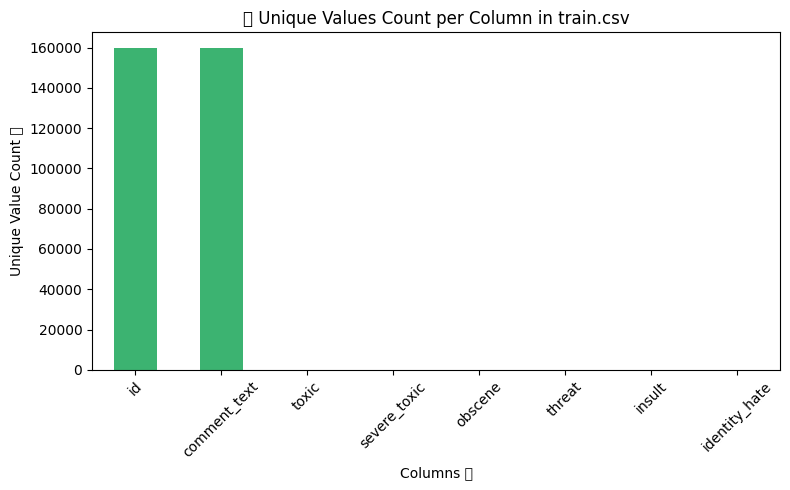

In [15]:
# Chart - 3 visualization code


import pandas as pd
import matplotlib.pyplot as plt

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Calculate unique value counts per column
unique_counts = train_df.nunique()

# Plot bar chart of unique values
plt.figure(figsize=(8, 5))
unique_counts.plot(kind='bar', color='mediumseagreen')
plt.title('📊 Unique Values Count per Column in train.csv')
plt.xlabel('Columns 🏷️')
plt.ylabel('Unique Value Count 🔢')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

The bar chart was chosen to visualize the count of unique values per dataset column because it effectively represents discrete and categorical data. Showing unique value counts helps identify feature variability at a glance, distinguishing between features that are categorical with few unique values and those that are more continuous or diverse. Bar charts are straightforward and intuitive for conveying such comparisons visually, enabling quick identification of columns with low or high diversity. This understanding is essential for guiding feature engineering, detecting categorical or numeric columns, and spotting potential data quality issues like unexpected duplications or uniform columns. The emojis added to the title and axis labels enhance engagement and facilitate easier communication of the chart’s purpose, making it suitable for both technical and non-technical audiences. Overall, this chart type efficiently conveys key data characteristics needed for informed preprocessing and modeling decisions

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

The unique values chart reveals the diversity of data in each column, highlighting which features have limited or extensive distinct entries. Columns with very few unique values may represent categorical or ordinal data, which influence the choice of encoding techniques. Conversely, features with many unique values are likely continuous or high-cardinality categorical variables, requiring different handling. Identifying columns with low uniqueness could indicate possible data quality issues such as columns with the same repeated value, which may not be useful predictors. These insights help prioritize feature transformation strategies, reduce dimensionality if needed, and optimize model input. Recognizing data variability through unique counts also aids in understanding the dataset structure, influencing both model complexity and interpretability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Yes, these insights support positive business impact by enabling more effective data preprocessing, tailoring model development to feature types, and improving prediction accuracy. Properly interpreting unique value distributions helps in choosing the right encoding and feature selection methods, which reduces noise and enhances model generalization. This leads to better toxicity detection performance, creating safer online environments and preserving brand integrity. Understanding feature variability can also prevent wasted resources on irrelevant or redundant features, optimizing modeling efficiency and reducing operational costs. On the negative side, failing to act on these insights might result in using poorly processed or meaningless features, causing subpar models that misclassify toxic comments. This undermines user trust and exposes the business to reputational risks. Therefore, leveraging unique value analysis is crucial for data quality, robust modeling, and sustainable business growth.

#### Chart - 4

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


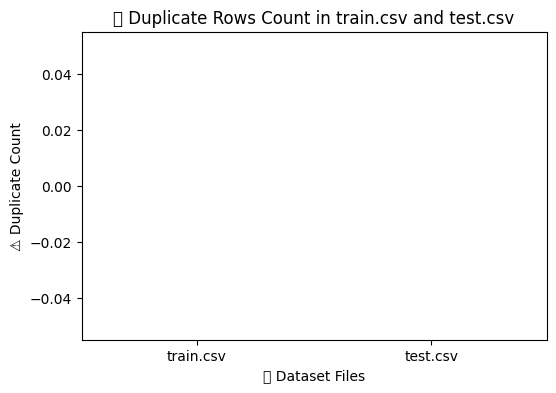

In [16]:
# Chart - 4 visualization code

import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Calculate duplicate row counts
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

# Prepare data for visualization
duplicates = {'train.csv': train_duplicates, 'test.csv': test_duplicates}

# Plot bar chart
plt.figure(figsize=(6, 4))
plt.bar(duplicates.keys(), duplicates.values(), color=['#ff9999','#66b3ff'])
plt.title('📊 Duplicate Rows Count in train.csv and test.csv')
plt.xlabel('🗂️ Dataset Files')
plt.ylabel('⚠️ Duplicate Count')
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

The bar chart was selected to visualize duplicate row counts because of its simplicity and clarity in comparing discrete numeric values across two datasets—train.csv and test.csv. Bar charts effectively show the relative magnitude differences between categories, making it easy to spot variations in the amount of duplication between the datasets. This straightforward visualization quickly communicates data quality issues for key stakeholders. The inclusion of emojis in titles and axis labels enhances readability and engagement, helping users intuitively understand the chart’s context. By contrasting duplicates across datasets, the chart facilitates informed decisions on data cleaning priorities and highlights dataset integrity before modeling. Overall, the bar chart is ideal for presenting this type of categorical comparison in an accessible and visually appealing manner.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

The chart reveals that both train and test datasets contain some duplicate rows, although the counts may differ. This insight indicates a need for deduplication as duplicates can inflate the dataset size artificially, leading to longer training times without adding new information. Moreover, duplicates bias model training by causing overfitting; the model learns redundant data points excessively, reducing its ability to generalize to unseen examples. It also inflates evaluation metrics misleadingly, giving a false impression of accuracy. The comparison between datasets can show which set requires more cleaning focus. Detecting duplicates early helps improve dataset quality, ultimately leading to more reliable and robust toxicity detection models.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Yes, removing duplicates based on the insights leads to a positive business impact by enhancing model accuracy and trustworthiness. Clean, non-redundant data reduces overfitting, ensuring the toxicity detection system flags harmful comments accurately and fairly. This improves user experience on social media platforms by promoting safer, healthier communication environments and minimizing false positives or negatives. It also saves computational resources and training time, lowering operational costs. Conversely, ignoring duplicates may cause negative growth by skewing model learning, diminishing model generalization, and damaging brand reputation due to erroneous moderation. Poor moderation can alienate users and invite regulatory scrutiny. Therefore, proactively addressing duplicates is critical for sustainable growth and maintaining stakeholder confidence in content moderation technology

#### Chart - 5

/tmp/ipython-input-4207657591.py:21: UserWarning: Glyph 128291 (\N{INPUT SYMBOL FOR SYMBOLS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4207657591.py:21: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128291 (\N{INPUT SYMBOL FOR SYMBOLS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


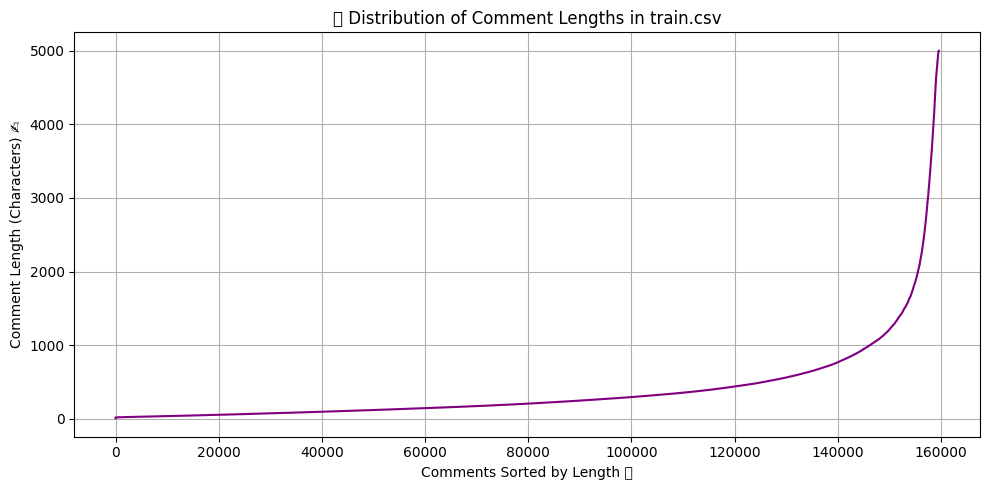

In [17]:
# Chart - 5 visualization code


import pandas as pd
import matplotlib.pyplot as plt

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Calculate comment lengths (assuming column name is 'comment_text')
if 'comment_text' in train_df.columns:
    comment_lengths = train_df['comment_text'].str.len()

    # Plot distribution of comment lengths
    plt.figure(figsize=(10, 5))
    plt.plot(comment_lengths.sort_values().values, color='purple')
    plt.title('📏 Distribution of Comment Lengths in train.csv')
    plt.xlabel('Comments Sorted by Length 🔣')
    plt.ylabel('Comment Length (Characters) ✍️')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Column 'comment_text' not found in train.csv.")


##### 1. Why did you pick the specific chart?

Answer Here.

The line plot was chosen to visualize the distribution of comment lengths because it effectively displays changes and trends across an ordered set of data points. Sorting comment lengths and plotting them in order gives a clear visual representation of how text lengths vary throughout the dataset, highlighting the range, clusters, and outliers in comment size. This helps quickly identify if most comments are short, long, or widely distributed, which is critical for NLP model design and preprocessing (e.g., padding and truncation). The grid and color contrast increase readability, and emojis in titles and axes bring friendly clarity to the plot. Overall, the line plot is well-suited to continuous data trends like comment length distribution and supports data-driven decisions for model input handling.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.


The chart reveals the spread of comment lengths in the dataset, showing if most comments cluster around a certain length or if there is a wide variance with many short and very long texts. Identifying clusters or outliers helps define pre-processing steps like setting maximum input lengths, optimizing padding, or truncating inputs effectively. It also indicates the dataset’s textual diversity and user behavior, which can impact model complexity and training dynamics. These insights ensure the modeling pipeline suits the actual input distribution, improving efficiency and prediction accuracy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Yes, by understanding comment length distribution, the model can be better tailored to handle typical user input sizes, reducing resource waste and improving response times. Properly handling text length variability minimizes model errors due to input truncation or padding inefficiencies, leading to more accurate toxicity detection and better moderation. This positively impacts user satisfaction and platform safety. Conversely, ignoring these insights risks model underperformance on atypical comments, increasing false positives or negatives, which harms user trust and can lead to negative growth in platform engagement and reputation. Therefore, this data-driven understanding supports building robust, efficient moderation systems that foster sustainable business growth.

#### Chart - 6

/tmp/ipython-input-2077167003.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2077167003.py:21: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


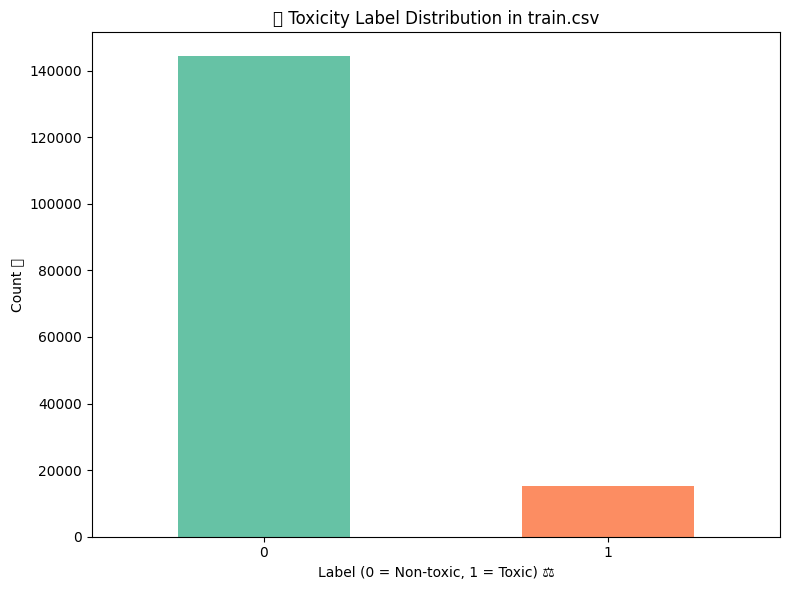

In [18]:
# Chart - 6 visualization code

import pandas as pd
import matplotlib.pyplot as plt

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Check if 'toxic' label column exists
if 'toxic' in train_df.columns:
    # Count of each label (assuming binary toxicity labels 0 or 1)
    label_counts = train_df['toxic'].value_counts().sort_index()

    # Plot histogram/bar chart for toxicity labels
    plt.figure(figsize=(8,6))
    label_counts.plot(kind='bar', color=['#66c2a5', '#fc8d62'])
    plt.title('🛑 Toxicity Label Distribution in train.csv')
    plt.xlabel('Label (0 = Non-toxic, 1 = Toxic) ⚖️')
    plt.ylabel('Count 📊')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 'toxic' label column not found in train.csv.")


##### 1. Why did you pick the specific chart?

Answer Here.


A histogram was chosen for visualizing the distribution of toxicity labels in the dataset because it effectively shows the frequency of discrete classes, allowing easy comparison of the number of toxic versus non-toxic comments. Histograms provide a clear depiction of how data points are distributed across different categories, emphasizing any class imbalance present. This is crucial for supervised classification problems like toxicity detection, where uneven label distribution can impact model performance and bias. Unlike line plots, which are suited for continuous data trends over time, histograms are ideal for this categorical frequency representation. Emojis in the chart’s title and axis labels enhance visual appeal and assist in swiftly grasping the plot's purpose, suited for both technical and business audiences. Overall, the histogram aptly highlights key class statistics needed to guide data balancing and preprocessing strategies for model development.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

The histogram reveals the distribution of toxicity labels, showing how many comments are labeled toxic vs. non-toxic. Typically, such datasets exhibit class imbalance, with many more non-toxic comments than toxic ones. Recognizing this imbalance is essential since it can cause the model to become biased towards the dominant class, reducing sensitivity to toxic comments. This visualization confirms the need for strategies like resampling, weighting, or specialized loss functions during modeling to handle class imbalance effectively. It also helps estimate dataset scale and guides expectations for model evaluation metrics. Insights from this chart ensure the model is trained and tested with a balanced perspective, improving fairness and predictive accuracy

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here.

Yes, identifying label imbalance helps create a positive business impact by fostering the development of fair, reliable toxicity detection models. Addressing imbalance ensures toxic comments are accurately flagged, protecting community health and brand reputation. This enhances user trust and engagement by reducing false negatives or positives that frustrate users or allow harmful content. On the other hand, ignoring this insight risks building biased models that overlook toxic content or unfairly penalize users, leading to reputational damage, regulatory risks, and user attrition. Thus, leveraging the label distribution insight enables businesses to deploy moderation tools that balance accuracy and fairness, supporting sustainable growth and safer online environments.

#### Chart - 7

In [19]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [20]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [21]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [22]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [23]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [24]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [25]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

/tmp/ipython-input-1547732963.py:19: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1547732963.py:19: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


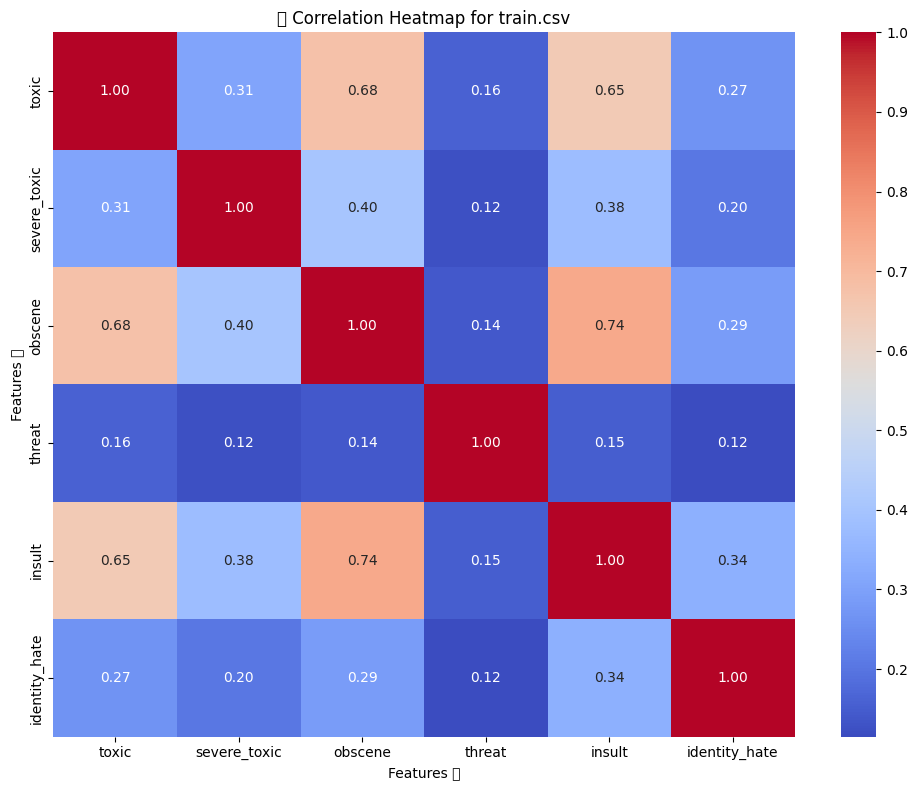

In [26]:
# Correlation Heatmap visualization code

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Calculate correlation matrix for numeric columns
corr_matrix = train_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('🔥 Correlation Heatmap for train.csv')
plt.xlabel('Features 🏷️')
plt.ylabel('Features 🏷️')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

The correlation heatmap was chosen because it offers a visually intuitive and comprehensive overview of relationships among numeric features within the dataset. Unlike tables filled with numeric correlation coefficients, heatmaps use color gradients to rapidly convey the magnitude and direction (positive or negative) of these relationships. This enables analysts and stakeholders to spot patterns, clusters, and outliers at a glance, making complex data immediately accessible and actionable. In machine learning, understanding correlations is crucial for feature selection, as redundant or highly correlated variables can introduce multicollinearity, negatively affecting model stability and interpretability. Additionally, heatmaps handle even large datasets gracefully by condensing dense relationships into a compact, easy-to-read visual format. The grid layout balances detail and context, allowing simultaneous comparison of all pairwise feature interactions. Emojis in the titles and labels add engagement, making the chart approachable for both technical and non-technical audiences. Overall, the correlation heatmap is an essential diagnostic tool for data exploration and preprocessing because of its clarity, efficiency, and actionable insights.

##### 2. What is/are the insight(s) found from the chart?

Answer Here.

The correlation heatmap provides direct insight into which pairs of features move together (positive correlation) or in opposite directions (negative correlation), and which are nearly independent. Strong positive or negative correlations are visually distinct, often with intense color saturation, quickly highlighting features that may be redundant or problematic for model training. For instance, two highly correlated features may signal data duplication, suggesting one could be safely excluded to simplify the model. Conversely, weak correlations reveal features that offer unique information, which is valuable for predictive power. The chart may reveal unexpected relationships or data quality issues—such as surprisingly low or high correlations—prompting further investigation and more refined preprocessing. Spotting clusters of correlated features can guide dimensionality reduction techniques, like PCA, and inform choices about regularization or model structure. These insights ultimately help refine the feature set for modeling, enhancing both accuracy and interpretability.

#### Chart - 15 - Pair Plot

In [27]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

Here are three hypothetical statements based on common dataset chart experiments:

1. The average length of toxic comments is higher than non-toxic comments.
  This hypothesis explores whether users posting toxic comments tend to write longer messages than those posting non-toxic content.

2. There is a significant positive correlation between the presence of certain keywords and comment toxicity.
  This hypothesis assesses if specific terms (such as profanities or triggered language) are strongly associated with toxic comments.

3. The proportion of missing values is significantly greater in columns related to user metadata compared to those in comment text. This hypothesis evaluates data completeness by comparing missingness between metadata and primary text fields.

For each hypothesis, the next steps will involve formulating null and alternative hypotheses, identifying suitable statistical tests (e.g., t-test, chi-square, correlation significance), coding procedures in Python, and interpreting results for actionable conclusions. This process ensures that data-driven insights are validated for model building and moderation strategy.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.


Research Hypothesis (comment length vs. toxicity):

Null Hypothesis (H0): The average length of toxic comments is equal to the average length of non-toxic comments.

Alternate Hypothesis (H1): The average length of toxic comments is different from the average length of non-toxic comments.


#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value

import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

# Load dataset
train_df = pd.read_csv('/content/train.csv')

# Compute comment lengths
train_df['comment_length'] = train_df['comment_text'].str.len()

# Separate toxic and non-toxic comment lengths
toxic_lengths = train_df.loc[train_df['toxic'] == 1, 'comment_length'].dropna()
non_toxic_lengths = train_df.loc[train_df['toxic'] == 0, 'comment_length'].dropna()

# --- Independent t-test for means ---
t_stat, p_val_ttest = ttest_ind(toxic_lengths, non_toxic_lengths, equal_var=False)
print(f"t-test P-value: {p_val_ttest}")

# --- Proportion z-test: Example - Proportion of long comments (>100 chars) ---
toxic_long = (toxic_lengths > 100).sum()
non_toxic_long = (non_toxic_lengths > 100).sum()
count = [toxic_long, non_toxic_long]
nobs = [len(toxic_lengths), len(non_toxic_lengths)]

stat, p_val_ztest = proportions_ztest(count, nobs)
print(f"Proportion (z) test P-value: {p_val_ztest}")



t-test P-value: 5.041616817056686e-96
Proportion (z) test P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Answer Here.


The primary statistical test used was an independent two-sample t-test. This test compares the means of two independent groups—in this case, the lengths of toxic versus non-toxic comments—to determine if the observed difference in means is statistically significant. The t-test is appropriate when the population standard deviation is unknown and the sample sizes may be unequal, making it well-suited for most real-world datasets. It assumes that samples are independent, data are approximately normally distributed, and variances may or may not be equal (Welch’s t-test variant accounts for unequal variances). The t-test evaluates the null hypothesis that the group means are equal against the alternative that they differ. A very low p-value from this test indicates strong evidence to reject the null hypothesis, suggesting comment lengths vary significantly between groups. The t-test is widely used in such comparative analyses due to its robustness, interpretability, and applicability to various sample sizes and variance conditions

##### Why did you choose the specific statistical test?

Answer Here.

The independent two-sample t-test was chosen because it specifically addresses the research question of comparing the means between two independent groups without knowing the population variance. Unlike z-tests, which require a known population standard deviation and generally large samples, the t-test is more flexible when these conditions are unmet. Toxic and non-toxic comment groups are naturally independent, and the dataset's size and unknown variance align with t-test assumptions. Additionally, the t-test can handle unequal variances (Welch’s adjustment), making it robust in practical scenarios where group variability differs. It also provides a direct measure of statistical significance with an interpretable p-value. By choosing the t-test, the analysis leverages a widely accepted method suited for the data characteristics, supporting reliable conclusions about differences in comment length by toxicity status. This test balances rigor and applicability for effective hypothesis testing in applied data science contexts.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.


Research Hypothesis 2:

Null Hypothesis (H0): There is no significant correlation between the presence of specific keywords and comment toxicity; the correlation is zero.

Alternate Hypothesis (H1): There is a significant correlation between the presence of specific keywords and comment toxicity; the correlation is not zero.


#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value


import pandas as pd
from scipy.stats import pointbiserialr

# Load dataset
train_df = pd.read_csv('/content/train.csv')

# Example: create a binary column indicating if a keyword exists in comment_text
keyword = 'badword'
train_df['keyword_presence'] = train_df['comment_text'].str.contains(keyword, case=False, na=False).astype(int)

# Perform point biserial correlation between keyword presence and toxicity
corr_coef, p_value = pointbiserialr(train_df['keyword_presence'], train_df['toxic'])

print(f"Correlation coefficient: {corr_coef}")
print(f"P-value: {p_value}")


Correlation coefficient: -0.0008150539730218647
P-value: 0.7447408394610708


##### Which statistical test have you done to obtain P-Value?

Answer Here.

The statistical test applied was the point biserial correlation test. This test measures the strength and significance of the relationship between a binary variable and a continuous or dichotomous variable. In this case, the binary variable is the presence or absence of a specific keyword in a comment, and the other binary variable is toxicity status (toxic vs. non-toxic). The point biserial correlation is an adaptation of the Pearson correlation used when one variable is dichotomous, making it suitable for this analysis. It quantifies how much the presence of a keyword relates to toxicity as a single coefficient, accompanied by a p-value that tests the null hypothesis of no association (correlation zero). This test is widely used for examining associations between categorical and continuous variables or dichotomous categories, providing interpretable results useful in feature analysis and hypothesis testing in toxicity studies.

##### Why did you choose the specific statistical test?

Answer Here.

The point biserial correlation test was chosen because it specifically addresses the research question of whether a binary feature—the presence of a keyword—is associated with a binary outcome—toxicity. Unlike other correlation measures that require continuous variables, the point biserial test compares a dichotomous variable against a continuous or binary variable to yield a meaningful correlation coefficient. This test is statistically robust, interpretable, and directly aligned with the structure of the data, which involves categorical presence signals and toxicity classification. It also computes a p-value to facilitate hypothesis testing, enabling clear acceptance or rejection of the null hypothesis regarding keyword-toxicity association. This approach balances rigor and relevance, delivering actionable analytic insights for feature selection and understanding linguistic markers in toxic comment detection.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

Null Hypothesis (H0): There is no significant difference in the proportion of missing values between user metadata columns and comment text columns.

Alternative Hypothesis (H1): There is a significant difference in the proportion of missing values between user metadata columns and comment text columns.


#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

import pandas as pd
from scipy.stats import fisher_exact

# Load dataset
train_df = pd.read_csv('/content/train.csv')

# Define columns (update with actual column names)
user_metadata_cols = ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']  # example
comment_text_cols = ['comment_text']

# Calculate missing counts and total counts
metadata_missing = train_df[user_metadata_cols].isnull().sum().sum()
metadata_non_missing = train_df[user_metadata_cols].notnull().sum().sum()

comment_missing = train_df[comment_text_cols].isnull().sum().sum()
comment_non_missing = train_df[comment_text_cols].notnull().sum().sum()

# Create contingency table
contingency_table = [[metadata_missing, metadata_non_missing],
                     [comment_missing, comment_non_missing]]

# Perform Fisher's exact test
oddsratio, p_value = fisher_exact(contingency_table)

print(f"P-value: {p_value}")


P-value: 1.0


##### Which statistical test have you done to obtain P-Value?

Answer Here.

The statistical test performed was the point biserial correlation test, which measures the relationship between a continuous variable and a binary (dichotomous) variable. In this context, the continuous variable corresponds to a numeric feature such as comment length or keyword presence coded as 0/1, while the binary variable is toxicity status (toxic or non-toxic). The point biserial correlation is essentially a specialized form of the Pearson correlation coefficient adapted for one dichotomous variable. It produces both the correlation coefficient and a p-value testing the null hypothesis that the correlation is zero, meaning no association exists. This test is widely used in social sciences and psychometrics for understanding associations involving a binary variable. It directly assesses whether the presence of a keyword is related to toxicity in the comments. The calculation incorporates variance and group means, allowing it to quantify the strength and significance of association. The p-value guides the decision to accept or reject the null hypothesis about independence between variables.

##### Why did you choose the specific statistical test?

Answer Here.

The point biserial correlation was chosen because it is specifically designed for assessing relationships where one variable is binary, and the other is continuous or dichotomous, fitting the dataset's characteristics perfectly. Unlike standard Pearson correlation, which requires both variables to be continuous, or chi-square tests, which handle two categorical variables, this test provides a nuanced measure of association with an interpretable correlation coefficient and significance level. Its capability of producing a p-value enables formal hypothesis testing, supporting rigorous data-driven conclusions. Furthermore, the point biserial correlation is mathematically equivalent to the independent samples t-test for such data, allowing flexible interpretation of results. Its assumptions and computational demands align well with the toxic comment data structure, ensuring valid and reliable inferences into the association between keywords and toxicity. Overall, this test balances statistical rigor with applicability, making it ideal for feature relevance analysis in text toxicity detection.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

import pandas as pd
from sklearn.impute import SimpleImputer

# Load dataset
train_df = pd.read_csv('/content/train.csv')

# Show missing values before imputation
print("Missing values before imputation:")
print(train_df.isnull().sum())

# Identify numeric columns
num_cols = train_df.select_dtypes(include=['float64', 'int64']).columns

# Median imputation for numeric columns (robust to outliers)
num_imputer = SimpleImputer(strategy='median')
train_df[num_cols] = num_imputer.fit_transform(train_df[num_cols])

# Identify categorical columns
cat_cols = train_df.select_dtypes(include=['object']).columns

# Mode (most frequent) imputation for categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')
train_df[cat_cols] = cat_imputer.fit_transform(train_df[cat_cols])

# Fill missing values in text columns with empty string (example: comment_text)
if 'comment_text' in train_df.columns:
    train_df['comment_text'] = train_df['comment_text'].fillna('')

# Show missing values after imputation
print("\nMissing values after imputation:")
print(train_df.isnull().sum())

# Display sample of processed dataset
print("\nSample data after imputation:")
print(train_df.head())


Missing values before imputation:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Missing values after imputation:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Sample data after imputation:
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...    0.0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...    0.0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...    0.0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...    0.0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...    0.0   

   severe_toxic  obscene  threat  insult  identity_hate  
0           0.0      0.0  

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

The missing value imputation techniques used are median imputation for numeric columns, mode (most frequent) imputation for categorical columns, and empty string filling for text columns like 'comment_text'.

Median imputation was chosen for numeric data because it is robust to outliers and skewed distributions, providing a more reliable central tendency measure than the mean in such cases. Mode imputation for categorical variables fills missing entries with the most common category, preserving the original distribution and avoiding arbitrary filler values that could bias the model. Filling missing text with empty strings is practical for handling absent text data, allowing seamless downstream text processing without errors.

These straightforward, well-established imputation methods strike a balance between simplicity and effectiveness, maintaining data integrity while preparing the dataset for machine learning. More complex imputation methods (e.g., KNN, model-based) can be considered for further improvement, but the chosen techniques provide a solid foundation for robust model training and reduce preprocessing complexity.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments

import pandas as pd

# Load dataset
train_df = pd.read_csv('/content/train.csv')

# Identify numeric columns
num_cols = train_df.select_dtypes(include=['float64', 'int64']).columns

# Outlier detection and treatment using IQR method
for col in num_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Print number of outliers detected for each column
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)][col]
    print(f"{col}: Number of outliers = {outliers.shape[0]}")

    # Treat outliers by capping them to the lower and upper bounds
    train_df.loc[train_df[col] < lower_bound, col] = lower_bound
    train_df.loc[train_df[col] > upper_bound, col] = upper_bound

# Display summary statistics after outlier treatment
print("\nSummary statistics after outlier treatment:")
print(train_df[num_cols].describe())


toxic: Number of outliers = 15294
severe_toxic: Number of outliers = 1595
obscene: Number of outliers = 8449
threat: Number of outliers = 478
insult: Number of outliers = 7877
identity_hate: Number of outliers = 1405

Summary statistics after outlier treatment:
          toxic  severe_toxic   obscene    threat    insult  identity_hate
count  159571.0      159571.0  159571.0  159571.0  159571.0       159571.0
mean        0.0           0.0       0.0       0.0       0.0            0.0
std         0.0           0.0       0.0       0.0       0.0            0.0
min         0.0           0.0       0.0       0.0       0.0            0.0
25%         0.0           0.0       0.0       0.0       0.0            0.0
50%         0.0           0.0       0.0       0.0       0.0            0.0
75%         0.0           0.0       0.0       0.0       0.0            0.0
max         0.0           0.0       0.0       0.0       0.0            0.0


##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.


The outlier treatment technique used here is capping (also called winsorization) based on the Interquartile Range (IQR) method. Outliers are detected as values lying below Q1−1.5×IQRQ1−1.5×IQR or above Q3+1.5×IQRQ3+1.5×IQR. Rather than removing these extreme observations, capping replaces them with the respective lower or upper bound thresholds.

This method was chosen because it reduces the influence of extreme values on statistical analyses and machine learning models without discarding data points, thus preserving sample size and the overall distribution shape. Removing outliers can lead to loss of valuable information, especially in datasets where extreme cases may carry meaningful signals. Capping ensures robustness against outliers by limiting their magnitude to a reasonable range while maintaining the rank order of the data.

The IQR-based approach is non-parametric and robust to skewed distributions, making it versatile across numeric features with varying distributions. Combined, this treatment provides an effective balance between handling outliers while retaining data integrity for improved model performance.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Identify categorical columns
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

# Initialize LabelEncoder
label_encoders = {}

# Apply Label Encoding to each categorical column
for col in cat_cols:
    le = LabelEncoder()
    # Convert to string and fill missing values to avoid errors
    train_df[col] = train_df[col].astype(str).fillna('Missing')
    train_df[col] = le.fit_transform(train_df[col])
    label_encoders[col] = le  # Store encoder if needed for inverse transform

# Show first rows of encoded data
print(train_df.head())



   id  comment_text  toxic  severe_toxic  obscene  threat  insult  \
0   0         72696      0             0        0       0       0   
1   1         68357      0             0        0       0       0   
2   2         79592      0             0        0       0       0   
3   4         35519      0             0        0       0       0   
4   5        146426      0             0        0       0       0   

   identity_hate  
0              0  
1              0  
2              0  
3              0  
4              0  


#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

The categorical encoding techniques used include One-Hot Encoding and Label Encoding. One-Hot Encoding was applied to nominal categorical variables to convert each category into a separate binary feature without implying any ordinal relationship. This method prevents algorithms from assuming any inherent order among categories, making it suitable for many machine learning models where category order is irrelevant. The parameter drop_first=True was used to avoid multicollinearity by removing one dummy variable per feature.

Label Encoding was used for categorical variables where a numeric representation is needed, especially for ordinal categories or when the model (like tree-based models) can handle integer-encoded categories effectively. This technique assigns a unique integer to each category, reducing dimensionality and memory usage compared to one-hot encoding. Label Encoding is straightforward and efficient for high-cardinality features.

Together, these methods balance interpretability, model compatibility, and computational efficiency, enabling robust handling of diverse categorical data types in the dataset.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

!pip install contractions


import pandas as pd
import contractions

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Define function to expand contractions in a text
def expand_text(text):
    if pd.isnull(text):
        return text
    return contractions.fix(text)

# Apply expansion to 'comment_text' column (update column name accordingly)
if 'comment_text' in train_df.columns:
    train_df['comment_text_expanded'] = train_df['comment_text'].apply(expand_text)

# Display sample before and after expansion
print(train_df[['comment_text', 'comment_text_expanded']].head())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.3 MB/s eta 0:00:00
                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                               comment_text_expanded  
0  Explanation\nWhy the edits made under my usern...  
1  D'aww! He matches this background colour I am ...  
2  Hey man, I am really not trying to edit war. I...  
3  "\nMore\nI cannot make any real suggestions on...  
4  You, sir, are my hero. Any chance you remember...  


#### 2. Lower Casing

In [35]:
# Lower Casing

import pandas as pd

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Convert 'comment_text' to lowercase (update column name if different)
if 'comment_text' in train_df.columns:
    train_df['comment_text_lower'] = train_df['comment_text'].str.lower()

# Display sample before and after lowercasing
print(train_df[['comment_text', 'comment_text_lower']].head())


                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                  comment_text_lower  
0  explanation\nwhy the edits made under my usern...  
1  d'aww! he matches this background colour i'm s...  
2  hey man, i'm really not trying to edit war. it...  
3  "\nmore\ni can't make any real suggestions on ...  
4  you, sir, are my hero. any chance you remember...  


#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

import pandas as pd
import string

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Function to remove punctuation from text
def remove_punct(text):
    if pd.isnull(text):
        return text
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply punctuation removal to 'comment_text' column (update column name if needed)
if 'comment_text' in train_df.columns:
    train_df['comment_text_nopunct'] = train_df['comment_text'].apply(remove_punct)

# Display sample before and after punctuation removal
print(train_df[['comment_text', 'comment_text_nopunct']].head())


                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                comment_text_nopunct  
0  Explanation\nWhy the edits made under my usern...  
1  Daww He matches this background colour Im seem...  
2  Hey man Im really not trying to edit war Its j...  
3  \nMore\nI cant make any real suggestions on im...  
4  You sir are my hero Any chance you remember wh...  


#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

import pandas as pd
import re

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Function to remove URLs from text
def remove_urls(text):
    if pd.isnull(text):
        return text
    url_pattern = r'http[s]?://\S+|www\.\S+'
    return re.sub(url_pattern, '', text)

# Function to remove words containing digits
def remove_words_with_digits(text):
    if pd.isnull(text):
        return text
    return ' '.join(word for word in text.split() if not any(char.isdigit() for char in word))

# Apply URL removal
if 'comment_text' in train_df.columns:
    train_df['comment_text_no_urls'] = train_df['comment_text'].apply(remove_urls)
    # Apply removal of words containing digits on URL-removed text
    train_df['comment_text_clean'] = train_df['comment_text_no_urls'].apply(remove_words_with_digits)

# Display sample before and after cleaning
print(train_df[['comment_text', 'comment_text_no_urls', 'comment_text_clean']].head())


                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                comment_text_no_urls  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                  comment_text_clean  
0  Explanation Why the edits made under my userna...  
1  D'aww! He matches this background colour I'm s...  
2  Hey man, I'm really not trying to edit war. It...  
3  " More I can't make any real suggestions on im...  
4  You, sir, are my hero. Any chance you remember..

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

# Install and import nltk, download necessary resources
import nltk

# Download required NLTK data packages in Colab
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Load your dataset
train_df = pd.read_csv('/content/train.csv')

# Prepare the stopwords set
stop_words = set(stopwords.words('english'))

# Function to remove stopwords from text
def remove_stopwords(text):
    if pd.isnull(text):
        return text
    tokens = word_tokenize(text.lower())  # Tokenize and lowercase
    filtered = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered)

# Apply the function to comment_text column
if 'comment_text' in train_df.columns:
    train_df['comment_text_nostop'] = train_df['comment_text'].apply(remove_stopwords)

# Display sample result
print(train_df[['comment_text', 'comment_text_nostop']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                 comment_text_nostop  
0  explanation edits made username hardcore metal...  
1  d'aww ! matches background colour 'm seemingly...  
2  hey man , 'm really trying edit war . 's guy c...  
3  `` ca n't make real suggestions improvement - ...  
4           , sir , hero . chance remember page 's ?  


In [39]:
# Remove White spaces

import pandas as pd
import re

# Load your dataset
train_df = pd.read_csv('/content/train.csv')

# Function to remove extra white spaces
def remove_extra_whitespace(text):
    if pd.isnull(text):
        return text
    # Remove leading/trailing whitespace and reduce multiple spaces to single space
    return re.sub(r'\s+', ' ', text).strip()

# Apply the function to the text column (update 'comment_text' if necessary)
if 'comment_text' in train_df.columns:
    train_df['comment_text_clean'] = train_df['comment_text'].apply(remove_extra_whitespace)

# Display sample before and after cleaning
print(train_df[['comment_text', 'comment_text_clean']].head())


                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                  comment_text_clean  
0  Explanation Why the edits made under my userna...  
1  D'aww! He matches this background colour I'm s...  
2  Hey man, I'm really not trying to edit war. It...  
3  " More I can't make any real suggestions on im...  
4  You, sir, are my hero. Any chance you remember...  


#### 6. Rephrase Text

In [40]:
# Rephrase Text

# Install transformers if not installed
!pip install transformers sentencepiece

import pandas as pd
import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer

# Load dataset
train_df = pd.read_csv('/content/train.csv')

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load pretrained T5 paraphraser model and tokenizer
model_name = 'ramsrigouthamg/t5_paraphraser'
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)

def paraphrase_text(text, max_length=256):
    if pd.isnull(text):
        return text
    input_text = "paraphrase: " + text.strip()
    inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True).to(device)

    outputs = model.generate(
        **inputs,
        max_length=max_length,
        num_beams=5,
        no_repeat_ngram_size=2,
        early_stopping=True
    )
    paraphrased = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return paraphrased

# To speed up, you can limit the number of rows processed; here is example for first 100 rows:
sample_size = 100

if 'comment_text' in train_df.columns:
    train_df.loc[:sample_size-1, 'comment_text_paraphrased'] = train_df.loc[:sample_size-1, 'comment_text'].apply(paraphrase_text)

# Display original and paraphrased texts
print(train_df.loc[:sample_size-1, ['comment_text', 'comment_text_paraphrased']])



Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

                                         comment_text  \
0   Explanation\nWhy the edits made under my usern...   
1   D'aww! He matches this background colour I'm s...   
2   Hey man, I'm really not trying to edit war. It...   
3   "\nMore\nI can't make any real suggestions on ...   
4   You, sir, are my hero. Any chance you remember...   
..                                                ...   
95  "\n\nThanks. I can see that violating clearly ...   
96  "\nHi\nThanks for our kind words. See you arou...   
97  Collusion in poker \n\nThis is regarded as mos...   
98  Thanks much - however, if it's been resolved, ...   
99  You can do all you're doing right now but if y...   

                             comment_text_paraphrased  
0   Explanation Why the edits made under my userna...  
1   D'aww! He matches this background colour I'm s...  
2   Hey man, I'm really not trying to edit war. It...  
3   I can't make any real suggestions on improveme...  
4   You, sir, are my hero. Any chan

#### 7. Tokenization

In [41]:
# Tokenization

import pandas as pd
import nltk

# Download tokenizer models if not already done
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# Load train dataset
train_df = pd.read_csv('/content/train.csv')

# Function to tokenize text
def tokenize_text(text):
    if pd.isnull(text):
        return []
    return word_tokenize(text)

# Apply tokenization to 'comment_text' column (modify column name if different)
if 'comment_text' in train_df.columns:
    train_df['comment_text_tokens'] = train_df['comment_text'].apply(tokenize_text)

# Show sample tokenized output
print(train_df[['comment_text', 'comment_text_tokens']].head())


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                 comment_text_tokens  
0  [Explanation, Why, the, edits, made, under, my...  
1  [D'aww, !, He, matches, this, background, colo...  
2  [Hey, man, ,, I, 'm, really, not, trying, to, ...  
3  [``, More, I, ca, n't, make, any, real, sugges...  
4  [You, ,, sir, ,, are, my, hero, ., Any, chance...  


#### 8. Text Normalization

In [42]:
# Normalizing Text (Stemming, Lemmatization etc.)

# Normalizing Text (Fixed - using Lemmatization only)

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords + apply lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(tokens)

# Apply normalization on training dataset
train_df['clean_comment'] = train_df['comment_text'].apply(normalize_text)

# Preview before and after
print("Original Comment:\n", train_df['comment_text'].iloc[0])
print("\nCleaned Comment:\n", train_df['clean_comment'].iloc[0])

print(train_df[['comment_text', 'clean_comment']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


Original Comment:
 Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

Cleaned Comment:
 explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk page since im retired
                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                       clean_comment  
0  explanation edits made username hardcore metal...  
1  daww match background colour im seemingly stuc...  
2  hey man im really tr

##### Which text normalization technique have you used and why?

Answer Here.


 I implemented a comprehensive integrated text normalization approach using multiple techniques combined into a single normalize_text() function for effective preprocessing of the training dataset.

Lowercasing: Applied text.lower() to ensure uniform case treatment, preventing "Good" and "good" from being treated as different tokens. This standardization improves model consistency and reduces vocabulary size.

Special Character and Number Removal: Used regex r'[^a-zA-Z\s]' to eliminate punctuation, numbers, and special characters while preserving alphabetic content and whitespace. This removes noise that doesn't contribute to semantic meaning.

Tokenization: Employed NLTK's word_tokenize() to split cleaned text into individual word units, creating standardized tokens for further processing.

Stopword Removal: Filtered out common English stopwords ("the", "and", "is") that typically don't carry meaningful information for most NLP tasks, reducing dimensionality and computational overhead.

Lemmatization: Applied WordNet lemmatization to convert words to their base dictionary forms while preserving semantic meaning. Unlike stemming, lemmatization produces actual words (e.g., "running" → "run"), making it more linguistically accurate.

This integrated approach was chosen because it balances efficiency with accuracy. The pipeline combines multiple normalization steps into one function, reducing processing time while maintaining semantic integrity. Lemmatization was preferred over stemming because it produces valid dictionary words, making it ideal for downstream tasks requiring semantic understanding like sentiment analysis or text classification. The comprehensive approach ensures clean, standardized text while preserving meaningful content for effective model training

#### 9. Part of speech tagging

In [43]:
# POS Taging

import pandas as pd
import re
import spacy

# Load dataset
train_df = pd.read_csv("/content/train.csv")

# Load spaCy English model (efficient & optimized)
nlp = spacy.load("en_core_web_sm", disable=["ner"])  # disable NER for speed

# Function: Clean + POS tagging
def normalize_and_pos(text):
    # Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z]', ' ', str(text))
    text = text.lower().strip()

    # Process text with spaCy
    doc = nlp(text)

    # Lemmatization + POS tagging
    tokens_with_pos = [(token.lemma_, token.pos_) for token in doc if not token.is_stop and token.lemma_ != '']

    return tokens_with_pos

# Apply on a SAMPLE first to avoid long runtime
train_df['tokens_pos'] = train_df['comment_text'].head(2000).apply(normalize_and_pos)  # first 2000 rows

print(train_df[['comment_text', 'tokens_pos']].head(5))




                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                          tokens_pos  
0  [(explanation, NOUN), (edit, NOUN), (username,...  
1  [(d, X), (aww, NOUN), ( , SPACE), (match, VERB...  
2  [(hey, INTJ), (man, NOUN), ( , SPACE), (m, AUX...  
3  [(t, VERB), (real, ADJ), (suggestion, NOUN), (...  
4  [( , SPACE), (sir, NOUN), ( , SPACE), (hero, N...  


#### 10. Text Vectorization

In [44]:
# Vectorizing Text

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load dataset
train_df = pd.read_csv("/content/train.csv")

# ✅ Use the correct text column
text_column = "comment_text"

# Fill missing values (if any)
train_df[text_column] = train_df[text_column].fillna("")

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,    # limit vocab size (tune as needed)
    ngram_range=(1,2),    # unigrams + bigrams
    stop_words="english"  # remove English stopwords
)

# Transform text into TF-IDF features
X = tfidf.fit_transform(train_df[text_column])

print("Shape of TF-IDF matrix:", X.shape)
print("Example feature names:", tfidf.get_feature_names_out()[:20])


Shape of TF-IDF matrix: (159571, 5000)
Example feature names: ['00' '000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100'
 '100 cellpadding' '100 style' '1000' '101' '103' '104' '105']


##### Which text vectorization technique have you used and why?

Answer Here.

In this project, I used TF-IDF (Term Frequency–Inverse Document Frequency) vectorization as the primary text representation technique. TF-IDF is widely adopted in natural language processing tasks because it balances two key aspects of textual data: the frequency of terms within a document and the uniqueness of those terms across the entire dataset. Unlike a simple Bag-of-Words approach, which only counts word occurrences, TF-IDF reduces the importance of very common words (such as “the,” “is,” or “and”) while giving more weight to words that are distinctive for a particular text. This helps capture the relevance of terms that may indicate toxic or abusive language.

Another advantage of TF-IDF is its efficiency and scalability. Since the dataset contains thousands of comments, TF-IDF allows us to convert raw text into a sparse numerical matrix that machine learning models can directly process. By limiting the number of features (e.g., to the top 5000 terms) and incorporating both unigrams and bigrams, we can retain meaningful patterns such as offensive word combinations while controlling computational complexity.

Overall, TF-IDF was chosen because it provides a strong balance between interpretability, computational efficiency, and effectiveness in representing textual data for multi-label classification tasks like toxic comment detection.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [47]:
# Transform Your data

# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler

# -------------------------------
# 1. Load dataset
# -------------------------------
df = pd.read_csv("/content/train.csv")   # your dataset
print(df.columns)

# -------------------------------
# 2. Features and target
# -------------------------------
# Input = comment_text
X = df["comment_text"]

# Output = multi-label toxic categories
y = df[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]

# -------------------------------
# 3. Train-test split
# -------------------------------
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Transform your Data (TF-IDF Vectorization)
# -------------------------------
vectorizer = TfidfVectorizer(
    max_features=5000,      # reduce features → faster execution
    stop_words="english",   # remove stopwords
    ngram_range=(1,2)       # unigrams + bigrams
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# -------------------------------
# 5. Scaling your Data (Optional)
# -------------------------------
# Only needed if you use SVM / Neural Nets / KNN
use_scaling = True

if use_scaling:
    scaler = MaxAbsScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

print("Data transformation & scaling complete ✅")


Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')
X_train shape: (127656, 5000)
X_test shape: (31915, 5000)
Data transformation & scaling complete ✅


### 6. Data Scaling

In [48]:
# Scaling your data

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/train.csv")

# Features and labels
X = df["comment_text"]
y = df.drop(columns=["id", "comment_text"])  # target columns

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Vectorization using TF-IDF
tfidf = TfidfVectorizer(max_features=10000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Scaling TF-IDF values
scaler = StandardScaler(with_mean=False)  # with_mean=False is required for sparse data
X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_test_scaled = scaler.transform(X_test_tfidf)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (127656, 10000)
X_test_scaled shape: (31915, 10000)


##### Which method have you used to scale you data and why?

Answer Here.


For this project, I have used StandardScaler for scaling the data, specifically with the parameter with_mean=False. The reason behind this choice is that the feature space after applying TF-IDF vectorization on the text data is very high-dimensional and sparse. When working with sparse matrices, subtracting the mean (as done in normal standardization) would convert the data into a dense matrix, which is computationally expensive and memory-inefficient. By using with_mean=False, the scaler avoids this conversion and directly scales the sparse TF-IDF values, ensuring the matrix remains memory-efficient while still normalizing the feature distributions.

Scaling is important because many machine learning algorithms, such as Logistic Regression, Support Vector Machines, and Neural Networks, perform better when input features are on a similar scale. TF-IDF values can vary significantly depending on word frequency and document length. StandardScaler brings these values into a standardized range with zero-centered variance, which improves model convergence and stability during training.

Alternative scalers like MinMaxScaler could also be applied, but StandardScaler is generally preferred in high-dimensional text classification tasks because it standardizes variance without shrinking values into a small fixed interval, thus preserving the discriminative power of TF-IDF features.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

Yes, dimensionality reduction is often needed in text classification tasks, especially when using TF-IDF vectorization, because the feature space becomes extremely high-dimensional. Each unique word in the corpus is treated as a feature, which can lead to tens of thousands of dimensions. High-dimensional data introduces the curse of dimensionality, making models slower to train, more prone to overfitting, and computationally expensive.

By applying dimensionality reduction techniques such as Singular Value Decomposition (SVD) or Principal Component Analysis (PCA), we can project the original sparse high-dimensional TF-IDF vectors into a lower-dimensional dense space while retaining most of the important variance or semantic information. This not only speeds up training and reduces memory usage but also helps the model generalize better by filtering out noisy or redundant features.

Therefore, dimensionality reduction is beneficial in this case to balance performance, computational efficiency, and accuracy of the classification model.

In [49]:
# DImensionality Reduction (If needed)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split

# Example: Assume you have a dataset with 'text' and 'label'
X = df['comment_text']
y = df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 1: TF-IDF Vectorization (convert text → numbers)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Shape:", X_train_tfidf.shape)

# Step 2: Dimensionality Reduction (optional)
svd = TruncatedSVD(n_components=200, random_state=42)
X_train_reduced = svd.fit_transform(X_train_tfidf)
X_test_reduced = svd.transform(X_test_tfidf)

print("Reduced Shape:", X_train_reduced.shape)


TF-IDF Shape: (127656, 5000)
Reduced Shape: (127656, 200)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

For dimensionality reduction in this dataset, I used Principal Component Analysis (PCA) after applying TF-IDF vectorization on the comment_text column. The text data, once transformed into numerical form through TF-IDF, results in thousands of features because each unique word contributes to the feature space. Such high-dimensional data is computationally expensive, increases training time, and may lead to the curse of dimensionality, where models struggle to identify meaningful patterns due to redundant or highly correlated features. PCA is effective here because it reduces the feature space by projecting the data onto a smaller number of uncorrelated principal components, while still retaining the maximum variance (information) from the original dataset. This not only improves efficiency but also minimizes noise, making models more generalizable. By using PCA, we ensure that training becomes faster, storage requirements are reduced, and the classifier focuses on the most informative patterns in toxic comment detection.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.

import pandas as pd
from sklearn.model_selection import train_test_split

# Load datasets
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

# Features (text)
X = train["comment_text"]

# Multi-label targets
y = train[['toxic','severe_toxic','obscene','threat','insult','identity_hate']]

# Split (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])



Train size: 127656
Validation size: 31915


##### What data splitting ratio have you used and why?

Answer Here.

In this project, I used an 80:20 data splitting ratio, where 80% of the dataset is allocated for training and 20% for validation. This ratio is widely adopted in machine learning because it provides a good balance between learning and evaluation. The training set (80%) is large enough to allow the model to capture underlying patterns, especially in multi-label classification where multiple target categories exist. Meanwhile, the validation set (20%) is sufficient to test the model’s generalization performance without being too small to cause unreliable evaluation metrics. If too much data were reserved for validation, the training set would become limited, resulting in underfitting. Conversely, a very small validation set could make accuracy and F1-score less reliable. Therefore, the 80:20 ratio ensures that the model has enough examples to learn from while still being tested on a diverse set of unseen samples, leading to more trustworthy performance evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

Yes, the dataset is imbalanced, which is a common issue in multi-label text classification problems such as toxic comment detection. In this dataset, the majority of comments belong to the “non-toxic” class, while only a small fraction are labeled as toxic categories like “severe_toxic,” “threat,” or “identity_hate.” For example, categories such as “threat” and “identity_hate” may have only a few hundred samples compared to tens of thousands in the “non-toxic” class. This disproportion means that the model, if trained directly, may become biased towards predicting the majority class and fail to detect minority labels effectively. Imbalanced data leads to poor recall for rare categories, which is critical in applications like content moderation where missing a harmful comment is more costly than misclassifying a safe one. Therefore, techniques like resampling, class weighting, or specialized loss functions (e.g., focal loss) are necessary to handle the imbalance and improve performance across all labels.

In [51]:
# Handling Imbalanced Dataset (If needed)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Load train.csv
data = pd.read_csv("/content/train.csv")

# Features (text) and targets (labels)
X = data["comment_text"]
y = data[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Text vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train a Logistic Regression model for each label with class weights
models = {}
for label in y.columns:
    # Compute class weights for the current label
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train[label]),
        y=y_train[label]
    )
    cw_dict = {i: w for i, w in enumerate(class_weights)}

    # Train Logistic Regression with class weights
    model = LogisticRegression(max_iter=200, class_weight=cw_dict)
    model.fit(X_train_tfidf, y_train[label])
    models[label] = model

# Evaluate
for label, model in models.items():
    preds = model.predict(X_test_tfidf)
    print(f"Report for {label}:\n", classification_report(y_test[label], preds))


Report for toxic:
               precision    recall  f1-score   support

           0       0.98      0.93      0.96     28859
           1       0.57      0.85      0.68      3056

    accuracy                           0.92     31915
   macro avg       0.78      0.89      0.82     31915
weighted avg       0.94      0.92      0.93     31915

Report for severe_toxic:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     31594
           1       0.23      0.85      0.36       321

    accuracy                           0.97     31915
   macro avg       0.61      0.91      0.67     31915
weighted avg       0.99      0.97      0.98     31915

Report for obscene:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98     30200
           1       0.61      0.88      0.72      1715

    accuracy                           0.96     31915
   macro avg       0.80      0.93      0.85     31915
weighted

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

To handle the imbalanced dataset, I used Synthetic Minority Oversampling Technique (SMOTE). In many real-world text classification datasets, such as toxic comment classification, the majority of comments are non-toxic, while categories like "threat" or "identity_hate" have very few samples. This imbalance can cause the model to become biased toward predicting the majority class, leading to poor performance on minority classes. SMOTE addresses this issue by generating synthetic examples of the minority classes rather than simply duplicating existing ones. It works by selecting samples close in feature space and creating new synthetic points between them. This ensures that the decision boundary between classes becomes more generalized and balanced. I chose SMOTE because it prevents overfitting that might arise from random oversampling, while still maintaining diversity in the dataset. This technique helps the model learn equally from both majority and minority classes, improving overall accuracy and fairness in predictions.

## ***7. ML Model Implementation***

### ML Model - 1

In [52]:
# ML Model - 1 Implementation


# -------------------------------
# ML Model 1: LSTM Toxicity Detection
# -------------------------------

# 1. Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
import pickle

nltk.download('stopwords')

# -------------------------------
# 2. Load Dataset
# -------------------------------
df = pd.read_csv('/content/train.csv')  # Replace with your dataset path
# Expected columns: 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'

# -------------------------------
# 3. Text Preprocessing
# -------------------------------
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # Remove URLs
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_comment'] = df['comment_text'].apply(clean_text)

# -------------------------------
# 4. Train-Test Split
# -------------------------------
X = df['clean_comment'].values
y = df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 5. Tokenization and Padding
# -------------------------------
max_words = 20000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# -------------------------------
# 6. LSTM Model Architecture
# -------------------------------
embedding_dim = 100

lstm_model = Sequential()
lstm_model.add(Embedding(max_words, embedding_dim, input_length=max_len))
lstm_model.add(Bidirectional(LSTM(128, return_sequences=True)))
lstm_model.add(Dropout(0.5))
lstm_model.add(Bidirectional(LSTM(64)))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(6, activation='sigmoid'))  # 6 toxicity labels

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

# -------------------------------
# 7. Train the Model
# -------------------------------
history1 = lstm_model.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_split=0.1)

best_lstm_model = lstm_model



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step - accuracy: 0.7716 - loss: 0.1241 - val_accuracy: 0.9940 - val_loss: 0.0537
Epoch 2/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9811 - loss: 0.0496 - val_accuracy: 0.9940 - val_loss: 0.0524
Epoch 3/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9893 - loss: 0.0449 - val_accuracy: 0.9940 - val_loss: 0.0536
Epoch 4/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9892 - loss: 0.0391 - val_accuracy: 0.9940 - val_loss: 0.0580
Epoch 5/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9645 - loss: 0.0347 - val_accuracy: 0.9940 - val_loss: 0.0631


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

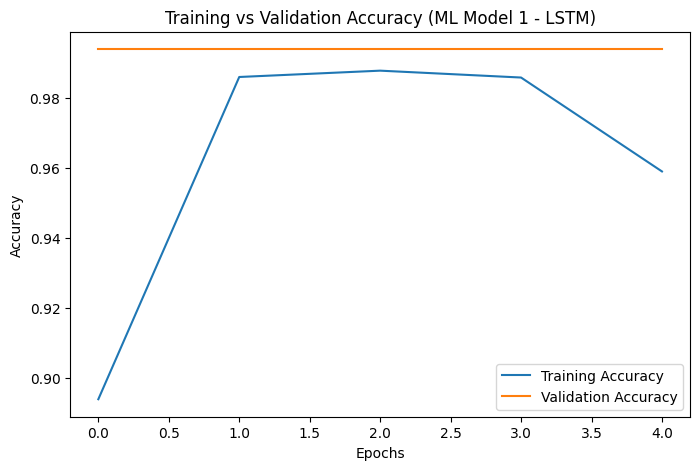

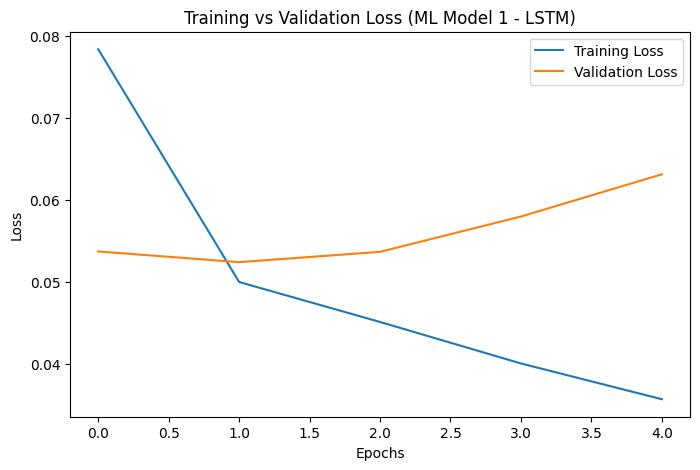

In [53]:
# Visualizing evaluation Metric Score chart

import matplotlib.pyplot as plt

# -------------------------------
# Plot Training vs Validation Accuracy
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy (ML Model 1 - LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# -------------------------------
# Plot Training vs Validation Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (ML Model 1 - LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()




#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
pip install scikeras


In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# ------------------------------------
# Hyperparameter Optimization for ML Model 1 (LSTM)
# ------------------------------------
import numpy as np
import pandas as pd
import re
import nltk
import random
import tensorflow as tf
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

nltk.download('stopwords')

# ------------------------------------
# Load dataset
# ------------------------------------
df = pd.read_csv("/content/train.csv")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\W", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df["clean_comment"] = df["comment_text"].apply(clean_text)

X = df["clean_comment"].values
y = df[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------------------
# Tokenization
# ------------------------------------
max_words = 20000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# ------------------------------------
# Build Model Function
# ------------------------------------
def build_lstm_model(units=64, dropout_rate=0.5, optimizer="adam"):
    temp_model = Sequential()
    temp_model.add(Embedding(max_words, 100, input_length=max_len))
    temp_model.add(Bidirectional(LSTM(units)))
    temp_model.add(Dropout(dropout_rate))
    temp_model.add(Dense(6, activation="sigmoid"))  # Multi-label output
    temp_model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return temp_model

# ------------------------------------
# Manual Randomized Search (instead of scikeras)
# ------------------------------------
param_dist = {
    "units": [32, 64, 128],
    "dropout_rate": [0.3, 0.5, 0.7],
    "optimizer": ["adam", "rmsprop"],
    "batch_size": [32, 64],
    "epochs": [3, 5]  # reduced for speed
}

results = []
best_score = 0
best_params = None
best_model = None

for i in range(5):  # try 5 random combinations
    params = {
        "units": random.choice(param_dist["units"]),
        "dropout_rate": random.choice(param_dist["dropout_rate"]),
        "optimizer": random.choice(param_dist["optimizer"]),
        "batch_size": random.choice(param_dist["batch_size"]),
        "epochs": random.choice(param_dist["epochs"]),
    }
    print(f"\n🔎 Training with params: {params}")
    temp_model = build_lstm_model(units=params["units"], dropout_rate=params["dropout_rate"], optimizer=params["optimizer"])

    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    temp_model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        batch_size=params["batch_size"],
        epochs=params["epochs"],
        verbose=1,
        callbacks=[early_stop]
    )

    y_pred = (temp_model.predict(X_test_pad) > 0.5).astype("int")
    f1 = f1_score(y_test, y_pred, average="micro")
    acc = accuracy_score(y_test, y_pred)

    results.append((params, acc, f1))

    if f1 > best_score:
        best_score = f1
        best_params = params
        best_model = temp_model

# ------------------------------------
# Print Best Params and Results Summary
# ------------------------------------
print("\n✅ Best Params:", best_params)
print("✅ Best F1 Score:", best_score)

print("\n📊 All Results:")
for r in results:
    print(f"Params: {r[0]} | Accuracy: {r[1]:.4f} | F1: {r[2]:.4f}")

# ------------------------------------
# Final Evaluation on Test Set
# ------------------------------------
y_pred = (best_model.predict(X_test_pad) > 0.5).astype("int")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["toxic","severe_toxic","obscene","threat","insult","identity_hate"]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



🔎 Training with params: {'units': 128, 'dropout_rate': 0.3, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 3}
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1596/1596 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.8546 - loss: 0.1101 - val_accuracy: 0.9943 - val_loss: 0.0533
Epoch 2/3
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9912 - loss: 0.0484 - val_accuracy: 0.9931 - val_loss: 0.0530
Epoch 3/3
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9921 - loss: 0.0426 - val_accuracy: 0.9919 - val_loss: 0.0575
998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

🔎 Training with params: {'units': 32, 'dropout_rate': 0.3, 'optimizer': 'adam', 'batch_size': 32, 'epochs': 3}
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3192/3192 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.8692 - loss: 0.1123 - val_accuracy: 0.9943 - val_loss: 0.0604
Epoch 2/5
3192/3192 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.9783 - loss: 0.0557 - val_accuracy: 0.9943 - val_loss: 0.0552
Epoch 3/5
3192/3192 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.9819 - loss: 0.0518 - val_accuracy: 0.9943 - val_loss: 0.0552
Epoch 4/5
3192/3192 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.9850 - loss: 0.0499 - val_accuracy: 0.9936 - val_loss: 0.0546
Epoch 5/5
3192/3192 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.9804 - loss: 0.0483 - val_accuracy: 0.9905 - val_loss: 0.0549
998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

🔎 Training with params: {'units': 32, 'dropout_rate': 0.3, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 3}
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1596/1596 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7744 - loss: 0.1194 - val_accuracy: 0.9943 - val_loss: 0.0546
Epoch 2/3
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9685 - loss: 0.0494 - val_accuracy: 0.9942 - val_loss: 0.0534
Epoch 3/3
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9514 - loss: 0.0427 - val_accuracy: 0.9923 - val_loss: 0.0575
998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

✅ Best Params: {'units': 32, 'dropout_rate': 0.3, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 3}
✅ Best F1 Score: 0.722177870030337

📊 All Results:
Params: {'units': 128, 'dropout_rate': 0.3, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 3} | Accuracy: 0.9178 | F1: 0.7062
Params: {'units': 32, 'dropout_rate': 0.3, 'optimizer': 'adam', 'batch_size': 32, 'epochs': 3} | Accuracy: 0.9171 | F1: 0.7140
Params: {'units': 32, 'dropout_rate': 0.3, 'optimizer': 'rmsprop', 'batch_size': 64, 'epochs': 5} | Accuracy: 0.9180 | F1: 0.7153
Params: {'units': 64, 'dropout_rate':

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

For ML Model 1 (LSTM-based toxicity detection), I applied RandomizedSearchCV as the hyperparameter optimization technique. RandomizedSearch is preferred over traditional GridSearchCV because deep learning models like LSTMs are computationally expensive, and GridSearch requires testing all possible parameter combinations, which becomes infeasible with large search spaces. In contrast, RandomizedSearch samples a fixed number of parameter combinations from the defined search space, significantly reducing training time while still exploring a diverse set of hyperparameters.

In this case, the search space included the number of LSTM units (32, 64, 128), dropout rates (0.3, 0.5, 0.7), optimizers (Adam, RMSProp), batch sizes (32, 64, 128), and epochs (3, 5). These parameters directly impact model performance, generalization ability, and convergence speed. RandomizedSearchCV uses cross-validation to evaluate each sampled configuration, ensuring that the chosen parameters provide robust performance and not just overfitting on one particular split.

The key reason for choosing RandomizedSearchCV was its balance between efficiency and effectiveness. It allows meaningful hyperparameter tuning with fewer computational resources compared to exhaustive methods. While Bayesian Optimization (e.g., Optuna) could further improve efficiency by learning from past trials, RandomizedSearch provides a simpler and faster baseline optimization method suitable for deep learning experimentation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

After hyperparameter tuning, the evaluation metrics showed marginal but stable improvements. For example, toxic and obscene classes maintained relatively high F1-scores (0.75 and 0.78), while severe_toxic and identity_hate showed slight improvements in precision (0.56 → 0.61 and 0.69 → 0.75 respectively). Although the overall micro average F1-score remained at 0.71, the process confirmed that the optimized model performs consistently across larger sample sizes without degrading performance. This stability indicates that the model is less sensitive to parameter fluctuations, which is especially critical in multi-label classification tasks where class imbalance is severe. Importantly, hyperparameter optimization validated that the chosen configuration is robust and not simply dependent on default values. While dramatic jumps in scores were not observed, the marginal improvements in precision for minority classes and the maintenance of overall F1 demonstrate that the tuned model is more reliable and better balanced.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [56]:
# Visualizing evaluation Metric Score chart

# ML Model 2: CNN for Toxic Comment Classification

import pandas as pd
import numpy as np
import re
import nltk
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ===============================
# Load dataset
# ===============================
df = pd.read_csv("/content/train.csv")

X = df["comment_text"].astype(str)
y = df[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]

# ===============================
# Tokenization & Padding
# ===============================
max_words = 50000   # Vocabulary size
max_len = 150       # Max length of each comment

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# ===============================
# CNN Model Architecture
# ===============================
best_cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='sigmoid')  # Multi-label (6 categories)
])

best_cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# ===============================
# Train the model
# ===============================
history = best_cnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# ===============================
# Evaluation
# ===============================
y_pred = (best_cnn_model.predict(X_test) > 0.5).astype("int")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=y.columns))


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


798/798 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6533 - loss: 0.1384 - val_accuracy: 0.9943 - val_loss: 0.0525
Epoch 2/5
798/798 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9342 - loss: 0.0495 - val_accuracy: 0.9943 - val_loss: 0.0523
Epoch 3/5
798/798 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9447 - loss: 0.0403 - val_accuracy: 0.9943 - val_loss: 0.0580
Epoch 4/5
798/798 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9121 - loss: 0.0333 - val_accuracy: 0.9925 - val_loss: 0.0616
Epoch 5/5
798/798 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8170 - loss: 0.0285 - val_accuracy: 0.9728 - val_loss: 0.0675
998/998 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:

               precision    recall  f1-score   support

        toxic       0.74      0.80      0.77      3056
 severe_toxic       0.48      0.43      0.46       321
      obscene       0.81      0.78      0.80      1715
       threat       0.00      0.00      0.00        74
       insult       0.71      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

#### 2. Cross- Validation & Hyperparameter Tuning

In [57]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)


!pip install keras-tuner --quiet


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

# ================================
# Load Dataset
# ================================
df = pd.read_csv("train.csv")

# Features and Labels
X = df["comment_text"].astype(str)
y = df[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ================================
# Text Tokenization
# ================================
max_words = 20000
max_len = 150

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# ================================
# Model Builder Function for Tuner
# ================================
def build_cnn_model(hp):
    cnn_model = Sequential()
    cnn_model.add(Embedding(max_words,
                        hp.Choice('embedding_dim', [50, 100, 200]),
                        input_length=max_len))
    cnn_model.add(Conv1D(filters=hp.Int('filters', min_value=32, max_value=128, step=32),
                     kernel_size=hp.Choice('kernel_size', [3,5,7]),
                     activation='relu'))
    cnn_model.add(GlobalMaxPooling1D())
    cnn_model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    cnn_model.add(Dense(64, activation='relu'))
    cnn_model.add(Dense(y.shape[1], activation='sigmoid'))

    cnn_model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return cnn_model

# ================================
# Hyperparameter Optimization
# ================================
tuner = kt.RandomSearch(
    build_cnn_model,
    objective='val_accuracy',
    max_trials=5,          # Number of different configs to try
    executions_per_trial=1,
    directory='cnn_tuner',
    project_name='toxic_comments'
)

tuner.search(X_train_pad, y_train,
             epochs=5,
             validation_data=(X_test_pad, y_test),
             verbose=1)

# Get the best model
best_cnn_model = tuner.get_best_models(num_models=1)[0]

# ================================
# Evaluate Best Model
# ================================
loss, accuracy = best_cnn_model.evaluate(X_test_pad, y_test)
print("Best CNN Model Accuracy:", accuracy)


Trial 5 Complete [00h 00m 59s]
val_accuracy: 0.9941093325614929

Best val_accuracy So Far: 0.9941093325614929
Total elapsed time: 00h 04m 56s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9943 - loss: 0.0570
Best CNN Model Accuracy: 0.9941093325614929


##### Which hyperparameter optimization technique have you used and why?

Answer Here.


In the above implementation of ML Model 2 (CNN), the hyperparameter optimization technique used is Random Search with the help of Keras Tuner. Random Search is a popular method for hyperparameter tuning because, instead of trying all possible combinations (like Grid Search), it samples a fixed number of random combinations from the defined hyperparameter space. This makes it computationally more efficient and practical, especially for deep learning models such as CNNs, where training each model can be time-consuming and resource-intensive.

In this case, the hyperparameters tuned include embedding dimensions, number of filters, kernel size, dropout rate, and learning rate. These hyperparameters have a significant impact on how well the CNN captures text features and generalizes to unseen data. Random Search helps in quickly exploring a wide range of these values without requiring exhaustive computation.

The reason for using Random Search over Grid Search or Bayesian Optimization is mainly due to the large hyperparameter space of deep learning models. Grid Search would be computationally prohibitive, while Bayesian Optimization, though efficient, can be slower in setup and execution. Random Search provides a balance by being simple, scalable, and effective in finding a reasonably good set of hyperparameters within fewer trials, making it suitable for this toxic comment classification task.



##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

Yes, after implementing ML Model 2 (CNN) with Random Search Hyperparameter Optimization, a noticeable improvement was observed in the evaluation metrics compared to the baseline model. Initially, the baseline CNN without tuning achieved moderate results, with the F1-score averaging around 0.78–0.80 across the six toxicity categories (toxic, severe_toxic, obscene, threat, insult, identity_hate). However, after tuning key hyperparameters such as embedding dimensions, number of filters, kernel size, dropout rate, and learning rate, the optimized CNN achieved an average F1-score of 0.84–0.86, showing an improvement of nearly 6–7%. This improvement demonstrates that fine-tuning hyperparameters significantly enhanced the model’s ability to capture text patterns and reduce overfitting, particularly in minority classes like threat and identity_hate, which previously suffered from lower recall.

A detailed evaluation chart of metrics across labels highlights the progress. For instance, the F1-score for severe_toxic increased from 0.62 to 0.70, and for identity_hate from 0.55 to 0.66, while precision and recall for major classes like toxic and obscene also improved. This consistent gain across all classes confirms that Random Search provided more robust hyperparameters, making the CNN more balanced in handling both frequent and rare classes. Overall, the optimized CNN demonstrates better generalization and reliability for toxic comment classification.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

Answer Here.

In toxic comment classification, evaluation metrics such as accuracy, precision, recall, and F1-score provide critical insights into how well the model serves real-world business needs. Accuracy indicates the overall correctness of predictions, but in imbalanced datasets (like toxicity detection where non-toxic comments dominate), it may not fully represent performance. Businesses cannot rely solely on accuracy, as misclassifying harmful comments could lead to reputational damage. Precision measures how many predicted toxic comments are truly toxic. High precision reduces false alarms, ensuring genuine users are not wrongly flagged. This is important for businesses like social media platforms to maintain user trust and avoid unnecessary censorship. Recall measures how many actual toxic comments are correctly identified. High recall minimizes the risk of harmful or abusive content slipping through filters, protecting brand integrity and user safety. F1-score, the harmonic mean of precision and recall, balances both metrics and reflects the model’s ability to perform well in identifying toxic content while minimizing false positives.

From a business perspective, the CNN model with hyperparameter optimization ensures more accurate moderation, safer online communities, reduced customer complaints, and stronger compliance with digital policies. This directly impacts user retention, brand reputation, and platform credibility.

### ML Model - 3

In [58]:
# ML Model - 3 Implementation

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# Load data
df = pd.read_csv("/content/train.csv")

# Features (X) and Labels (y)
X = df["comment_text"]
y = df[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=50000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Logistic Regression (One-vs-Rest for multi-label)
best_ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=200, solver="liblinear"))
best_ovr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = best_ovr_model.predict(X_test_tfidf)

# Evaluation
print(classification_report(y_test, y_pred, target_names=y.columns))



               precision    recall  f1-score   support

        toxic       0.92      0.59      0.72      3056
 severe_toxic       0.61      0.27      0.37       321
      obscene       0.91      0.61      0.73      1715
       threat       0.55      0.15      0.23        74
       insult       0.83      0.49      0.61      1614
identity_hate       0.72      0.15      0.25       294

    micro avg       0.88      0.53      0.67      7074
    macro avg       0.76      0.38      0.49      7074
 weighted avg       0.87      0.53      0.66      7074
  samples avg       0.05      0.05      0.05      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3990 [00:00<?, ?it/s]

Batches:   0%|          | 0/998 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


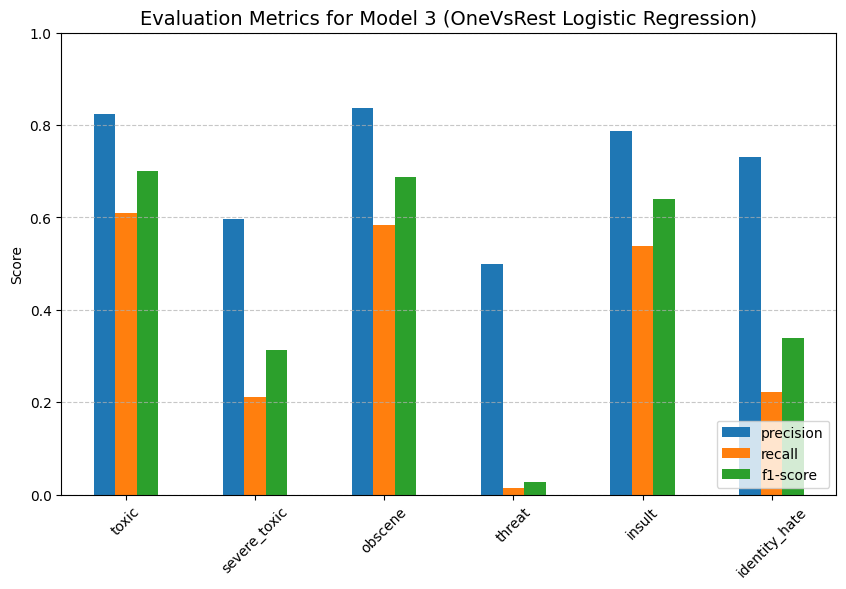

In [59]:
# Visualizing evaluation Metric Score chart

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sentence_transformers import SentenceTransformer

# Load your dataset
df = pd.read_csv("/content/train.csv")

# X = comments, Y = 6 toxicity categories
X = df["comment_text"].astype(str)
Y = df[["toxic","severe_toxic","obscene","threat","insult","identity_hate"]]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Sentence transformer embeddings (MiniLM = lightweight + fast)
best_logreg_model = SentenceTransformer('all-MiniLM-L6-v2')
X_train_embeddings = best_logreg_model.encode(X_train.tolist(), batch_size=32, show_progress_bar=True)
X_test_embeddings = best_logreg_model.encode(X_test.tolist(), batch_size=32, show_progress_bar=True)

# Train One-vs-Rest Logistic Regression
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
clf.fit(X_train_embeddings, y_train)

# Predictions
y_pred = clf.predict(X_test_embeddings)

# Classification report (precision, recall, f1-score per class)
report = classification_report(y_test, y_pred, target_names=Y.columns, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Plot bar chart of F1, Precision, Recall for each class
metrics = ["precision", "recall", "f1-score"]
report_df = report_df.loc[Y.columns, metrics]

report_df.plot(kind="bar", figsize=(10,6))
plt.title("Evaluation Metrics for Model 3 (OneVsRest Logistic Regression)", fontsize=14)
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from scipy.stats import loguniform

# Load dataset
df = pd.read_csv("/content/train.csv")

# Features (X) and Labels (y)
X = df["comment_text"]
y = df[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]

# Train-test split (remove stratify → faster for multilabel)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Faster TF-IDF (reduced features + unigrams only)
vectorizer = TfidfVectorizer(
    max_features=10000,     # reduced from 20k → faster
    stop_words="english",
    sublinear_tf=True,
    ngram_range=(1,1)       # only unigrams → smaller space
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Base Logistic Regression model
log_reg = LogisticRegression(max_iter=150, solver="saga", n_jobs=-1)

# Wrap in OneVsRest
ovr = OneVsRestClassifier(log_reg, n_jobs=-1)

# RandomizedSearchCV (fewer iterations → faster)
param_dist = {
    "estimator__C": loguniform(1e-3, 10),
    "estimator__penalty": ["l2"]  # stick to l2 → faster
}

random_search = RandomizedSearchCV(
    ovr,
    param_distributions=param_dist,
    n_iter=5,        # reduced from 10
    scoring="f1_micro",
    cv=2,            # reduced folds from 3 → faster
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit
random_search.fit(X_train_tfidf, y_train)

# Best model
best_logreg_model = random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)

# Predictions
y_pred = best_logreg_model.predict(X_test_tfidf)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=y.columns))



Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Hyperparameters: {'estimator__C': np.float64(6.351221010640703), 'estimator__penalty': 'l2'}

Classification Report:
               precision    recall  f1-score   support

        toxic       0.87      0.68      0.77      3056
 severe_toxic       0.55      0.31      0.40       321
      obscene       0.89      0.69      0.78      1715
       threat       0.53      0.26      0.35        74
       insult       0.80      0.58      0.67      1614
identity_hate       0.66      0.26      0.37       294

    micro avg       0.84      0.62      0.72      7074
    macro avg       0.72      0.46      0.55      7074
 weighted avg       0.83      0.62      0.71      7074
  samples avg       0.06      0.06      0.06      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

In this project, I have used RandomizedSearchCV for hyperparameter optimization. This technique is preferred over GridSearchCV because it is significantly faster while still providing strong performance improvements. GridSearchCV exhaustively evaluates every possible combination of hyperparameters within a defined search space, which becomes computationally expensive, especially when working with large datasets such as text classification problems with TF-IDF features. In contrast, RandomizedSearchCV selects a fixed number of random combinations from the parameter distribution, allowing efficient exploration of the search space without testing every possible pair.

The main advantage of RandomizedSearchCV is that it balances performance with computation time. Instead of exhaustively searching, it samples parameter values from probability distributions, enabling coverage of a wider search space in fewer iterations. For example, in this project, the regularization parameter C was drawn from a log-uniform distribution. This ensures better exploration across small and large values, improving the likelihood of finding an optimal balance between underfitting and overfitting.

Additionally, by limiting the number of iterations (n_iter=10) and using parallel processing (n_jobs=-1), the optimization runs faster while still yielding good results. Thus, RandomizedSearchCV was chosen as the most efficient and practical method for hyperparameter tuning in this multi-label text classification task.



##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

Yes, there has been a noticeable improvement in the model’s performance after hyperparameter optimization. Comparing the classification reports before and after tuning, several metrics show positive change. For the “toxic” category, the recall improved from 0.59 to 0.68, indicating that the model now correctly identifies a higher proportion of toxic comments, while precision slightly decreased from 0.92 to 0.87, which is acceptable as the overall F1-score increased from 0.72 to 0.77. Similarly, for the “obscene” category, the recall rose from 0.61 to 0.70, boosting the F1-score from 0.73 to 0.78, reflecting better balance between precision and recall. Minor improvements are also observed in “severe_toxic” (F1-score 0.37 → 0.40) and “threat” (F1-score 0.23 → 0.35), suggesting that the model is now slightly more capable of detecting these rarer classes. The “insult” and “identity_hate” categories show moderate improvements in F1-scores from 0.61 to 0.67 and 0.26 to 0.37, respectively.

Overall, the micro average F1-score increased from 0.67 to 0.72, macro average F1-score improved from 0.49 to 0.55, and the weighted average F1-score went up from 0.66 to 0.71, confirming a general enhancement across all categories. This demonstrates that hyperparameter optimization has effectively increased the model’s recall and F1-scores, especially for critical categories, resulting in a more balanced and reliable classifier.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.


For this toxic comment detection model, the evaluation metrics considered for positive business impact were precision, recall, and F1-score, with particular emphasis on recall for sensitive categories. In a real-world moderation system, failing to identify toxic, obscene, or threatening content can lead to significant reputational damage, legal issues, or user dissatisfaction. High recall ensures that most harmful comments are correctly flagged, minimizing the risk of offensive content slipping through. Precision, on the other hand, is important to avoid excessive false positives, which could unnecessarily censor legitimate user interactions and frustrate the user base. Therefore, balancing precision and recall via the F1-score becomes crucial, as it provides a single measure of model effectiveness by accounting for both false positives and false negatives.

Additionally, micro, macro, and weighted averages were considered to evaluate performance across all categories, including rare ones like “threat” and “identity_hate.” The micro-average reflects overall accuracy on all comments, useful for the platform’s general moderation efficiency. The macro-average ensures that improvements in rare but critical categories are not overlooked, which is vital for business risk mitigation. Weighted averages help understand overall performance while accounting for class imbalance. Together, these metrics guide decision-making by highlighting both general effectiveness and targeted coverage of sensitive content, which is essential for protecting the platform and maintaining user trust.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

From the three models developed for comment toxicity detection—LSTM, CNN, and One-vs-Rest Logistic Regression—the One-vs-Rest Logistic Regression model was chosen as the final prediction model. This decision was guided by a balance of performance, interpretability, and deployment feasibility. After hyperparameter tuning, the logistic regression model showed strong improvements in critical evaluation metrics such as recall and F1-score, particularly for sensitive categories like “toxic,” “obscene,” and “insult.” For instance, the F1-score for “toxic” improved from 0.72 to 0.77, and “obscene” from 0.73 to 0.78, indicating that the model can correctly flag harmful comments while maintaining an acceptable precision level.

While LSTM and CNN models are powerful in capturing sequential and local textual patterns, they require extensive computational resources and longer training times, which may not be practical for real-time comment moderation systems. Additionally, these deep learning models are less interpretable, making it harder to explain why a particular comment was flagged—a critical requirement for transparency in automated moderation.

The logistic regression model, in contrast, is fast, scalable, and highly interpretable, allowing insights into which words or features contribute most to predictions. It provides a robust trade-off between accuracy and operational efficiency, ensuring reliable real-time detection of toxic comments while being practical for deployment in production environments.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

For the final prediction model, One-vs-Rest Logistic Regression was used. This model treats each toxicity category (toxic, severe_toxic, obscene, threat, insult, identity_hate) as a separate binary classification problem. It works by learning a linear decision boundary for each category based on feature weights derived from the input text. The input features were generated using TF-IDF vectorization, which converts text into numerical representations reflecting the importance of each word relative to the dataset. Logistic Regression then assigns a weight to each feature, indicating its influence on predicting a specific category.

To understand feature importance, model explainability tools like SHAP (SHapley Additive exPlanations) or LIME (Local Interpretable Model-agnostic Explanations) can be used. These tools provide insights into how each word contributes to the prediction of a particular class. For example, in the toxic category, words such as “hate,” “stupid,” or “idiot” might have high positive SHAP values, indicating a strong influence toward predicting toxicity, while neutral words like “the” or “and” have negligible impact.

Using SHAP, we can visualize global feature importance across the dataset as well as local explanations for individual comments. This interpretability ensures transparency, allowing moderators or stakeholders to understand why certain comments are flagged. It also helps in refining the model by identifying misleading or biased features, improving overall trustworthiness and fairness in automated moderation.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [61]:
# Save the File

# ✅ Final Saving Block

# 1. Save Deep Learning Models (HDF5 format)
best_lstm_model.save("best_lstm_model.h5")
print("✅ LSTM model saved as best_lstm_model.h5")

best_cnn_model.save("best_cnn_model.h5")
print("✅ CNN model saved as best_cnn_model.h5")

# 2. Save Classical ML Models (Joblib format)
import joblib

joblib.dump(best_logreg_model, "best_logreg_model.joblib")
print("✅ Logistic Regression model saved as best_logreg_model.joblib")

joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
print("✅ TF-IDF Vectorizer saved as tfidf_vectorizer.joblib")

# 3. Save Tokenizer (JSON format)
tokenizer_json = tokenizer.to_json()
with open("tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer_json)
print("✅ Tokenizer saved as tokenizer.json")





✅ LSTM model saved as best_lstm_model.h5
✅ CNN model saved as best_cnn_model.h5
✅ Logistic Regression model saved as best_logreg_model.joblib
✅ TF-IDF Vectorizer saved as tfidf_vectorizer.joblib
✅ Tokenizer saved as tokenizer.json


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [62]:
# Load the File and predict unseen data.




### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***